# Step 6 Analysis: PC vs LiNGAM Comparison

Analysis of Shapley values from the experimental pipeline for **mixed_no_conf_f50_s1000_p50** dataset with **LGBM** model.

This notebook explores:
- PC vs LiNGAM comparison for top 10 features
- SHAP value distributions across methods
- Method agreement and correlations
- Detailed feature-level analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, pearsonr
from PIL import Image

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
BASE_DIR = Path('/Users/juanrios/Documents/master_thesis')
EXPLAINABILITY_DIR = BASE_DIR / 'data' / 'explainability'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
SYNTHETIC_DIR = BASE_DIR / 'data' / 'synthetic'

# Configuration
DATASET = 'mixed_no_conf_f50_s1000_p50'
MODEL = 'lgbm'

print(f"✓ Dataset: {DATASET}")
print(f"✓ Model: {MODEL}")

✓ Dataset: mixed_no_conf_f50_s1000_p50
✓ Model: lgbm


## 1. Load Data and Ground Truth

In [3]:
# Load metadata
import json

metadata_path = SYNTHETIC_DIR / f"{DATASET}_metadata.json"
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

y_parent_indices = metadata['y_parent_indices']
true_parents = set(y_parent_indices)

print(f"True Y parents (n={len(y_parent_indices)}): {sorted(y_parent_indices)}")
print(f"\nDataset info:")
print(f"  - Total features: {metadata['n_features']}")
print(f"  - Total samples: {metadata['n_samples']}")
print(f"  - Total edges in true graph: {metadata['n_edges']}")
print(f"  - Confounders: {metadata['n_confounders']}")

True Y parents (n=25): [0, 1, 2, 3, 5, 7, 8, 9, 11, 12, 17, 20, 21, 22, 25, 30, 33, 34, 35, 40, 45, 46, 47, 48, 49]

Dataset info:
  - Total features: 50
  - Total samples: 1000
  - Total edges in true graph: 291
  - Confounders: 0


In [4]:
# Load feature names
train_path = PROCESSED_DIR / f"{DATASET}_train.parquet"
train_data = pd.read_parquet(train_path)
X_train = train_data.drop(columns=['Y'])
feature_names = X_train.columns.tolist()

print(f"Feature names: {feature_names[:10]}... (showing first 10)")

Feature names: ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9']... (showing first 10)


## 2. Load SHAP Values

In [5]:
# Load SHAP values for all methods
base_path = EXPLAINABILITY_DIR / DATASET / MODEL

# Scratch (no causal graph)
scratch_path = base_path / 'scratch' / 'shapley_values.npy'
scratch_values = np.load(scratch_path)
scratch_importance = np.abs(scratch_values).mean(axis=0)

# PC methods
pc_asym_path = f"{base_path}/pc/asymmetric/shapley_values.npy"
pc_causal_path = f"{base_path}/pc/causal/shapley_values.npy"
# pc_flow_path = f"{base_path}/pc/flow/shapley_values.npy"
pc_flow_path = f"{base_path}/pc/flow_real/shapley_values.npy"


pc_asym_values = np.load(pc_asym_path)
pc_causal_values = np.load(pc_causal_path)
pc_flow_values = np.load(pc_flow_path)

pc_asym_importance = np.abs(pc_asym_values).mean(axis=0)
pc_causal_importance = np.abs(pc_causal_values).mean(axis=0)
pc_flow_importance = np.abs(pc_flow_values).mean(axis=0)

# LiNGAM methods
lingam_asym_path = base_path / 'lingam' / 'asymmetric' / 'shapley_values.npy'
lingam_causal_path = base_path / 'lingam' / 'causal' / 'shapley_values.npy'
lingam_flow_path = base_path / 'lingam' / 'flow' / 'shapley_values.npy'

lingam_asym_values = np.load(lingam_asym_path)
lingam_causal_values = np.load(lingam_causal_path)
lingam_flow_values = np.load(lingam_flow_path)

lingam_asym_importance = np.abs(lingam_asym_values).mean(axis=0)
lingam_causal_importance = np.abs(lingam_causal_values).mean(axis=0)
lingam_flow_importance = np.abs(lingam_flow_values).mean(axis=0)

print("✓ Loaded SHAP values for all methods")
print(f"  - SHAP values shape: {scratch_values.shape} (instances × features)")
print(f"  - Methods: Scratch, PC (Asym, Causal, Flow), LiNGAM (Asym, Causal, Flow)")

✓ Loaded SHAP values for all methods
  - SHAP values shape: (100, 50) (instances × features)
  - Methods: Scratch, PC (Asym, Causal, Flow), LiNGAM (Asym, Causal, Flow)


In [6]:
pc_flow_importance

array([0.00000000e+00, 0.00000000e+00, 9.97010618e-08, 0.00000000e+00,
       5.76071402e-06, 7.76427379e-06, 0.00000000e+00, 0.00000000e+00,
       1.37515254e-06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 2.96111050e-03, 2.76458100e-07,
       2.87828571e-03, 8.46075759e-06, 6.23754236e-03, 0.00000000e+00,
       0.00000000e+00, 1.68292924e-06, 5.19060608e-05, 1.67982674e-06,
       1.29018157e-02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 7.50014468e-02, 0.00000000e+00,
       1.75682206e-02, 6.90027745e-07, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.52749533e-02, 0.00000000e+00])

## 3. Display Pipeline Visualization

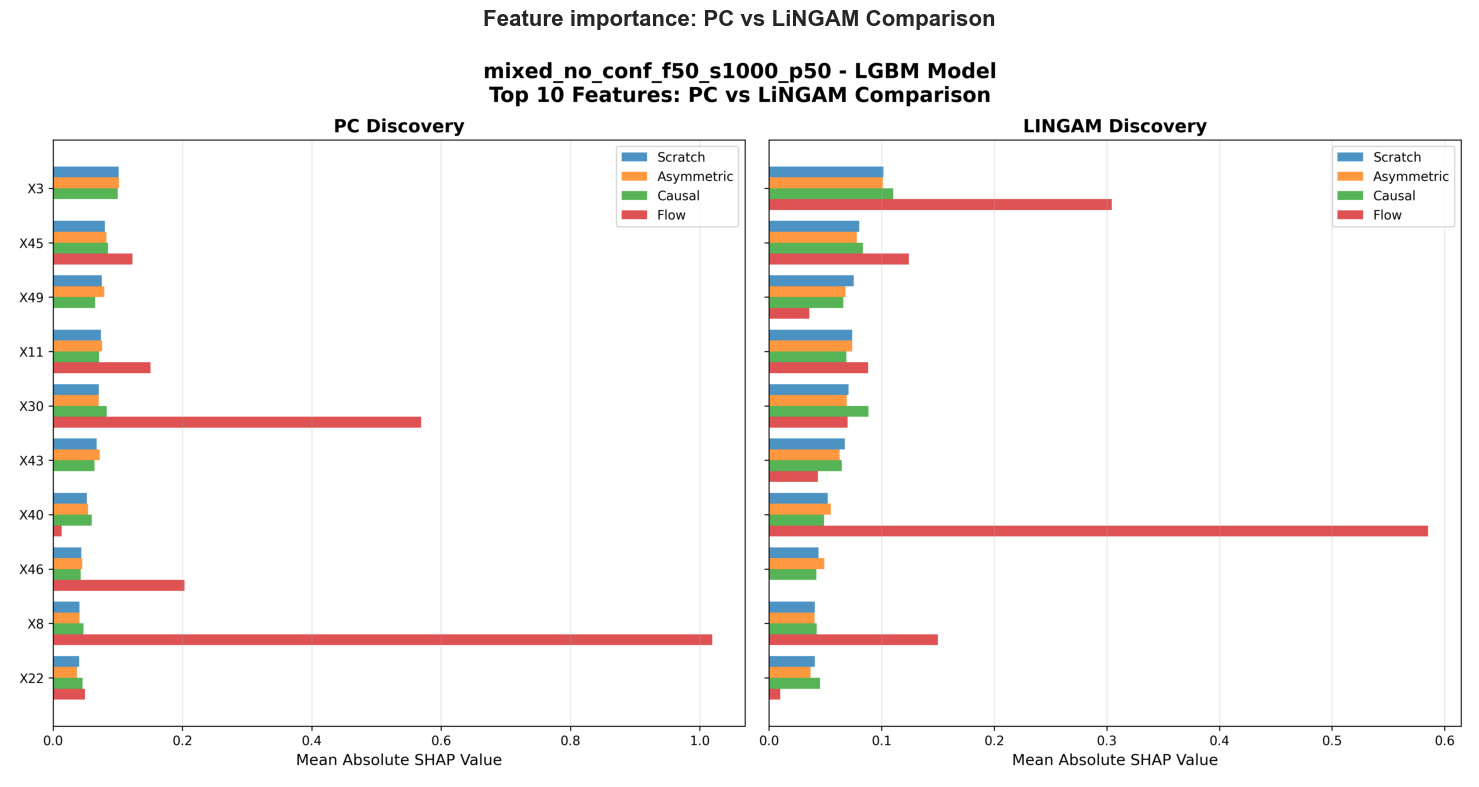

In [7]:
# Display the PC vs LiNGAM comparison created in Step 6
viz_path = base_path / 'pc_vs_lingam_comparison.png'

if viz_path.exists():
    img = Image.open(viz_path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Feature importance: PC vs LiNGAM Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️  Visualization not found at {viz_path}")

## 4. Top 10 Features Analysis

In [8]:
# Get top 10 features from Scratch
top_10_indices = np.argsort(scratch_importance)[-10:][::-1]
top_10_features = [feature_names[i] for i in top_10_indices]

print("Top 10 Features (by Scratch importance):")
print("="*60)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {scratch_importance[idx]:.4f} {is_parent}")

# Count how many are true parents
n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

Top 10 Features (by Scratch importance):
 1. X3    (idx= 3) - Importance: 0.1016 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0801 ✓ TRUE PARENT
 3. X49   (idx=49) - Importance: 0.0752 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0738 ✓ TRUE PARENT
 5. X30   (idx=30) - Importance: 0.0707 ✓ TRUE PARENT
 6. X43   (idx=43) - Importance: 0.0674 
 7. X40   (idx=40) - Importance: 0.0520 ✓ TRUE PARENT
 8. X46   (idx=46) - Importance: 0.0439 ✓ TRUE PARENT
 9. X8    (idx= 8) - Importance: 0.0408 ✓ TRUE PARENT
10. X22   (idx=22) - Importance: 0.0405 ✓ TRUE PARENT

→ 9/10 top features are true Y parents


In [9]:
# Get top 10 features from Assymetric PC
top_10_indices = np.argsort(pc_asym_importance)[-10:][::-1]
top_10_features = [feature_names[i] for i in top_10_indices]

print("Top 10 Features (by PC Asymmetric importance):")
print("="*60)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {pc_asym_importance[idx]:.4f} {is_parent}")

# Count how many are true parents
n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

Top 10 Features (by PC Asymmetric importance):
 1. X3    (idx= 3) - Importance: 0.1013 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0801 ✓ TRUE PARENT
 3. X49   (idx=49) - Importance: 0.0753 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0742 ✓ TRUE PARENT
 5. X43   (idx=43) - Importance: 0.0657 
 6. X30   (idx=30) - Importance: 0.0578 ✓ TRUE PARENT
 7. X40   (idx=40) - Importance: 0.0519 ✓ TRUE PARENT
 8. X46   (idx=46) - Importance: 0.0433 ✓ TRUE PARENT
 9. X37   (idx=37) - Importance: 0.0341 
10. X22   (idx=22) - Importance: 0.0334 ✓ TRUE PARENT

→ 8/10 top features are true Y parents


In [10]:
# Get top 10 features from Assymetric LiNGAM
top_10_indices = np.argsort(lingam_asym_importance)[-10:][::-1]
top_10_features = [feature_names[i] for i in top_10_indices]

print("Top 10 Features (by LiNGAM Asymmetric importance):")
print("="*60)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {lingam_asym_importance[idx]:.4f} {is_parent}")

# Count how many are true parents
n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

Top 10 Features (by LiNGAM Asymmetric importance):
 1. X3    (idx= 3) - Importance: 0.1011 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0780 ✓ TRUE PARENT
 3. X11   (idx=11) - Importance: 0.0739 ✓ TRUE PARENT
 4. X30   (idx=30) - Importance: 0.0689 ✓ TRUE PARENT
 5. X49   (idx=49) - Importance: 0.0677 ✓ TRUE PARENT
 6. X43   (idx=43) - Importance: 0.0628 
 7. X40   (idx=40) - Importance: 0.0548 ✓ TRUE PARENT
 8. X46   (idx=46) - Importance: 0.0491 ✓ TRUE PARENT
 9. X8    (idx= 8) - Importance: 0.0405 ✓ TRUE PARENT
10. X26   (idx=26) - Importance: 0.0376 

→ 8/10 top features are true Y parents


In [11]:
# Get top 10 features from Causal PC
top_10_indices = np.argsort(pc_causal_importance)[-10:][::-1]
top_10_features = [feature_names[i] for i in top_10_indices]

print("Top 10 Features (by Causal PC importance):")
print("="*60)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {pc_causal_importance[idx]:.4f} {is_parent}")

# Count how many are true parents
n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

Top 10 Features (by Causal PC importance):
 1. X3    (idx= 3) - Importance: 0.1001 ✓ TRUE PARENT
 2. X45   (idx=45) - Importance: 0.0851 ✓ TRUE PARENT
 3. X30   (idx=30) - Importance: 0.0831 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0710 ✓ TRUE PARENT
 5. X48   (idx=48) - Importance: 0.0675 ✓ TRUE PARENT
 6. X49   (idx=49) - Importance: 0.0650 ✓ TRUE PARENT
 7. X43   (idx=43) - Importance: 0.0642 
 8. X40   (idx=40) - Importance: 0.0598 ✓ TRUE PARENT
 9. X8    (idx= 8) - Importance: 0.0471 ✓ TRUE PARENT
10. X22   (idx=22) - Importance: 0.0456 ✓ TRUE PARENT

→ 9/10 top features are true Y parents


In [12]:
# Get top 10 features from LiNGAM Causal
top_10_indices = np.argsort(lingam_causal_importance)[-10:][::-1]
top_10_features = [feature_names[i] for i in top_10_indices]

print("Top 10 Features (by LiNGAM Causal importance):")
print("="*60)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {lingam_causal_importance[idx]:.4f} {is_parent}")

# Count how many are true parents
n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

Top 10 Features (by LiNGAM Causal importance):
 1. X3    (idx= 3) - Importance: 0.1104 ✓ TRUE PARENT
 2. X30   (idx=30) - Importance: 0.0882 ✓ TRUE PARENT
 3. X45   (idx=45) - Importance: 0.0833 ✓ TRUE PARENT
 4. X11   (idx=11) - Importance: 0.0686 ✓ TRUE PARENT
 5. X49   (idx=49) - Importance: 0.0658 ✓ TRUE PARENT
 6. X43   (idx=43) - Importance: 0.0647 
 7. X48   (idx=48) - Importance: 0.0566 ✓ TRUE PARENT
 8. X40   (idx=40) - Importance: 0.0489 ✓ TRUE PARENT
 9. X42   (idx=42) - Importance: 0.0474 
10. X22   (idx=22) - Importance: 0.0451 ✓ TRUE PARENT

→ 8/10 top features are true Y parents


In [13]:
# Get top 10 features from PC Flow
top_10_indices = np.argsort(pc_flow_importance)[-10:][::-1]
top_10_features = [feature_names[i] for i in top_10_indices]

print("Top 10 Features (by PC Flow importance):")
print("="*60)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {pc_flow_importance[idx]:.4f} {is_parent}")

# Count how many are true parents
n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

Top 10 Features (by PC Flow importance):
 1. X30   (idx=30) - Importance: 0.0750 ✓ TRUE PARENT
 2. X32   (idx=32) - Importance: 0.0176 
 3. X48   (idx=48) - Importance: 0.0153 ✓ TRUE PARENT
 4. X24   (idx=24) - Importance: 0.0129 
 5. X18   (idx=18) - Importance: 0.0062 
 6. X14   (idx=14) - Importance: 0.0030 
 7. X16   (idx=16) - Importance: 0.0029 
 8. X22   (idx=22) - Importance: 0.0001 ✓ TRUE PARENT
 9. X17   (idx=17) - Importance: 0.0000 ✓ TRUE PARENT
10. X5    (idx= 5) - Importance: 0.0000 ✓ TRUE PARENT

→ 5/10 top features are true Y parents


In [14]:
# Get top 10 features from LiNGAM Flow
top_10_indices = np.argsort(lingam_flow_importance)[-10:][::-1]
top_10_features = [feature_names[i] for i in top_10_indices]

print("Top 10 Features (by LiNGAM Flow importance):")
print("="*60)
for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_parent = "✓ TRUE PARENT" if idx in true_parents else ""
    print(f"{rank:2d}. {fname:5s} (idx={idx:2d}) - Importance: {lingam_flow_importance[idx]:.4f} {is_parent}")

# Count how many are true parents
n_true_parents_in_top10 = len([i for i in top_10_indices if i in true_parents])
print(f"\n→ {n_true_parents_in_top10}/10 top features are true Y parents")

Top 10 Features (by LiNGAM Flow importance):
 1. X42   (idx=42) - Importance: 1.6569 
 2. X19   (idx=19) - Importance: 0.8371 
 3. X33   (idx=33) - Importance: 0.7952 ✓ TRUE PARENT
 4. X10   (idx=10) - Importance: 0.5858 
 5. X40   (idx=40) - Importance: 0.5853 ✓ TRUE PARENT
 6. X27   (idx=27) - Importance: 0.5637 
 7. X7    (idx= 7) - Importance: 0.4805 ✓ TRUE PARENT
 8. X31   (idx=31) - Importance: 0.4740 
 9. X41   (idx=41) - Importance: 0.4612 
10. X47   (idx=47) - Importance: 0.4503 ✓ TRUE PARENT

→ 4/10 top features are true Y parents


In [15]:
# Get top 10 features from Scratch importance
top_10_indices = np.argsort(scratch_importance)[-10:][::-1]
top_10_features = [feature_names[i] for i in top_10_indices]

# Create detailed comparison table for top 10
comparison_data = []

for rank, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    comparison_data.append({
        'Rank': rank,
        'Feature': fname,
        'Index': idx,
        'True Parent': 'Yes' if idx in true_parents else 'No',
        'Scratch': scratch_importance[idx],
        'PC_Asym': pc_asym_importance[idx],
        'LiNGAM_Asym': lingam_asym_importance[idx],
        'PC_Causal': pc_causal_importance[idx],
        'LiNGAM_Causal': lingam_causal_importance[idx],
        'PC_Flow': pc_flow_importance[idx],
        'LiNGAM_Flow': lingam_flow_importance[idx],
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nDetailed comparison for Top 10 features:")
print(comparison_df.to_string(index=False))


Detailed comparison for Top 10 features:
 Rank Feature  Index True Parent  Scratch  PC_Asym  LiNGAM_Asym  PC_Causal  LiNGAM_Causal  PC_Flow  LiNGAM_Flow
    1      X3      3         Yes 0.101557 0.101325     0.101083   0.100141       0.110378 0.000000     0.304283
    2     X45     45         Yes 0.080144 0.080131     0.078005   0.085067       0.083345 0.000000     0.124133
    3     X49     49         Yes 0.075162 0.075305     0.067711   0.064951       0.065815 0.000000     0.035810
    4     X11     11         Yes 0.073760 0.074240     0.073921   0.071042       0.068610 0.000000     0.087840
    5     X30     30         Yes 0.070657 0.057806     0.068888   0.083096       0.088194 0.075001     0.069640
    6     X43     43          No 0.067374 0.065691     0.062761   0.064167       0.064660 0.000000     0.043271
    7     X40     40         Yes 0.051977 0.051870     0.054768   0.059772       0.048931 0.000000     0.585313
    8     X46     46         Yes 0.043878 0.043258     0.04913

## 5. Method Correlations

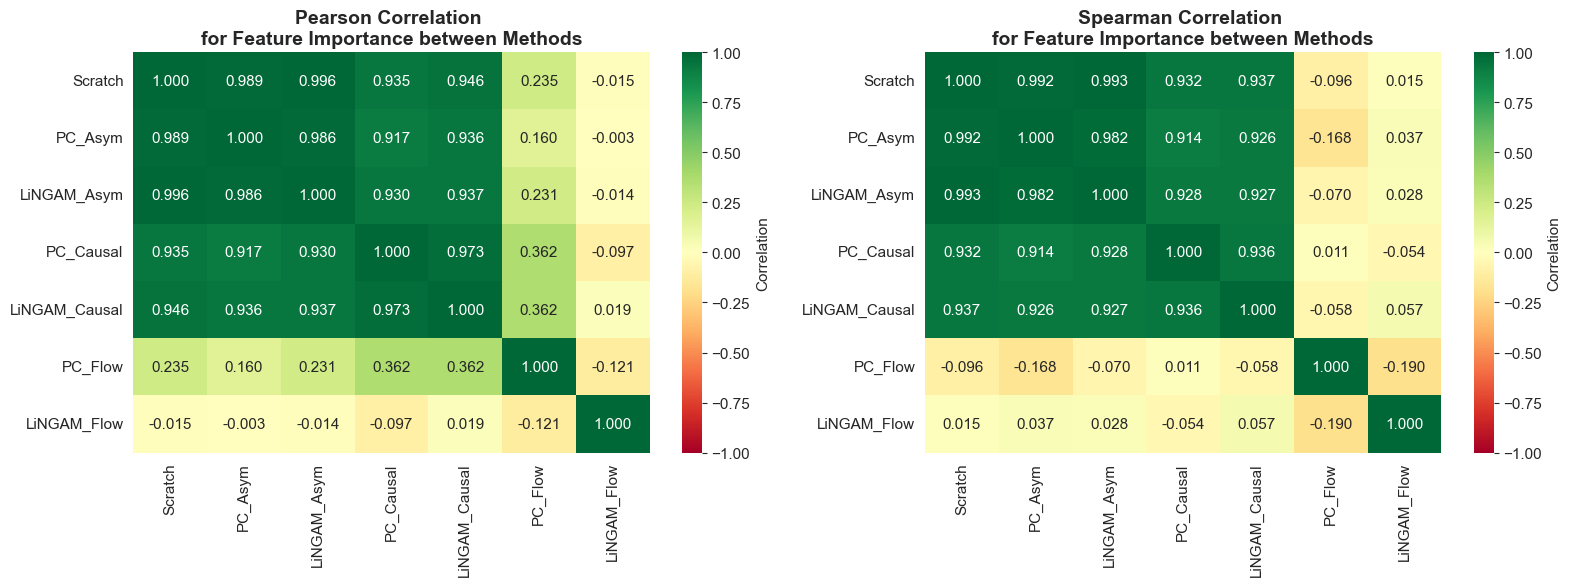


Key observations:
  - Scratch vs PC_Asym: Pearson=0.989, Spearman=0.992
  - Scratch vs LiNGAM_Asym: Pearson=0.946, Spearman=0.937
  - PC_Flow vs LiNGAM_Flow: Pearson=-0.097, Spearman=-0.054


In [16]:
# Calculate correlations between all methods
methods = {
    'Scratch': scratch_importance,
    'PC_Asym': pc_asym_importance,
    'LiNGAM_Asym': lingam_asym_importance,
    'PC_Causal': pc_causal_importance,
    'LiNGAM_Causal': lingam_causal_importance,
    'PC_Flow': pc_flow_importance,
    'LiNGAM_Flow': lingam_flow_importance,
}

# Compute correlation matrix
method_names = list(methods.keys())
n_methods = len(method_names)
corr_matrix_pearson = np.zeros((n_methods, n_methods))
corr_matrix_spearman = np.zeros((n_methods, n_methods))

for i, method1 in enumerate(method_names):
    for j, method2 in enumerate(method_names):
        pearson_corr, _ = pearsonr(methods[method1], methods[method2])
        spearman_corr, _ = spearmanr(methods[method1], methods[method2])
        corr_matrix_pearson[i, j] = pearson_corr
        corr_matrix_spearman[i, j] = spearman_corr

# Plot correlation heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson correlation
sns.heatmap(corr_matrix_pearson, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            xticklabels=method_names, yticklabels=method_names, 
            vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Pearson Correlation \nfor Feature Importance between Methods', fontsize=14, fontweight='bold')

# Spearman correlation
sns.heatmap(corr_matrix_spearman, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            xticklabels=method_names, yticklabels=method_names,
            vmin=-1, vmax=1, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Spearman Correlation \nfor Feature Importance between Methods', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"  - Scratch vs PC_Asym: Pearson={corr_matrix_pearson[0, 1]:.3f}, Spearman={corr_matrix_spearman[0, 1]:.3f}")
print(f"  - Scratch vs LiNGAM_Asym: Pearson={corr_matrix_pearson[0, 4]:.3f}, Spearman={corr_matrix_spearman[0, 4]:.3f}")
print(f"  - PC_Flow vs LiNGAM_Flow: Pearson={corr_matrix_pearson[3, 6]:.3f}, Spearman={corr_matrix_spearman[3, 6]:.3f}")

### 5.1 Instance-Level SHAP Value Correlations

While the previous analysis looked at correlations between aggregated feature importance values, this analysis examines correlations between the raw SHAP values themselves at the instance-feature level. This reveals how well methods agree on individual predictions.

Flattened SHAP value shapes:
  Scratch: (5000,)
  PC_Asym: (5000,)
  LiNGAM_Asym: (5000,)
  PC_Causal: (5000,)
  LiNGAM_Causal: (5000,)
  PC_Flow: (5000,)
  LiNGAM_Flow: (5000,)


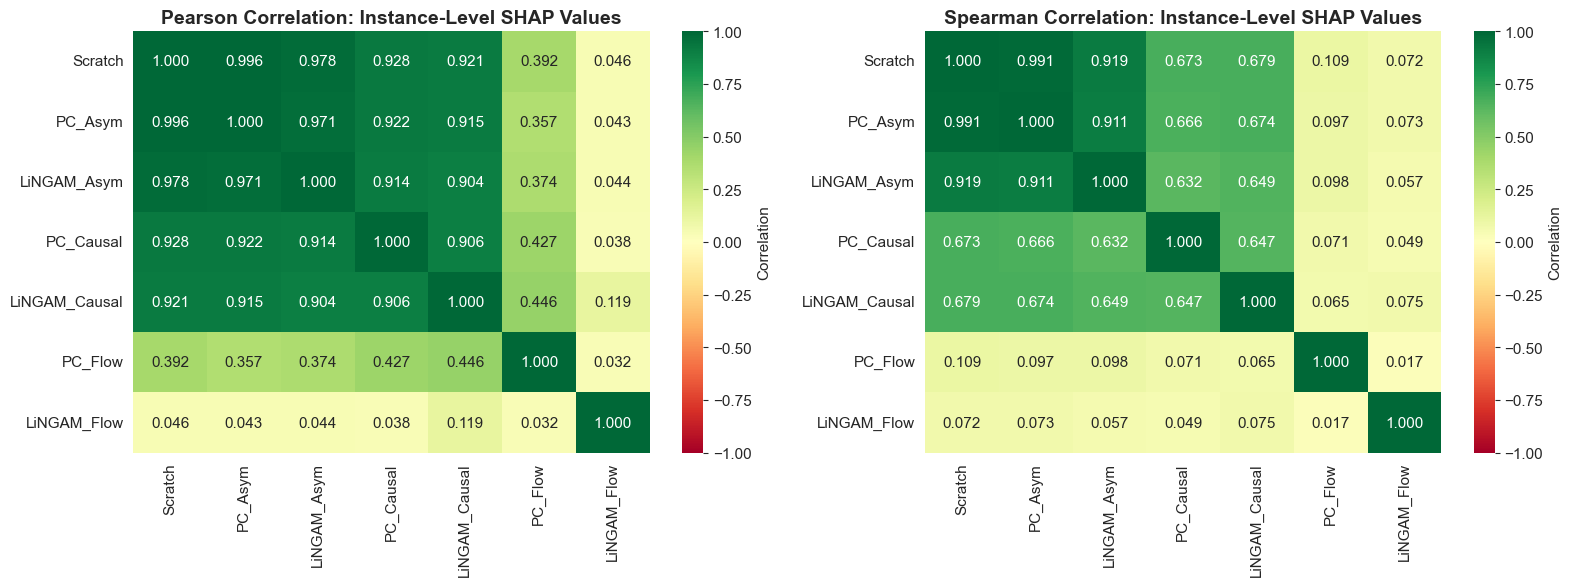


Instance-Level SHAP Value Correlations:
Key observations:
  - Scratch vs PC_Asym: Pearson=0.996, Spearman=0.991
  - Scratch vs LiNGAM_Asym: Pearson=0.978, Spearman=0.919
  - PC_Asym vs LiNGAM_Asym: Pearson=0.971, Spearman=0.911
  - PC_Flow vs LiNGAM_Flow: Pearson=0.032, Spearman=0.017

Comparison with Feature Importance Correlations:
Note: These correlations are typically lower than feature importance correlations
because they capture agreement at the instance-feature level, which is more
granular than aggregated importance values.


In [17]:
# Calculate correlations between raw SHAP values (instance-level)
# Flatten SHAP value matrices to compare entire distributions

shap_methods = {
    'Scratch': scratch_values,
    'PC_Asym': pc_asym_values,
    'LiNGAM_Asym': lingam_asym_values,
    'PC_Causal': pc_causal_values,
    'LiNGAM_Causal': lingam_causal_values,
    'PC_Flow': pc_flow_values,
    'LiNGAM_Flow': lingam_flow_values,
}

# Flatten each SHAP value matrix (instances × features) to 1D array
flattened_shap = {}
for method, shap_vals in shap_methods.items():
    flattened_shap[method] = shap_vals.flatten()

print("Flattened SHAP value shapes:")
for method, flat_vals in flattened_shap.items():
    print(f"  {method}: {flat_vals.shape}")

# Compute correlation matrices for raw SHAP values
shap_method_names = list(flattened_shap.keys())
n_shap_methods = len(shap_method_names)
shap_corr_pearson = np.zeros((n_shap_methods, n_shap_methods))
shap_corr_spearman = np.zeros((n_shap_methods, n_shap_methods))

for i, method1 in enumerate(shap_method_names):
    for j, method2 in enumerate(shap_method_names):
        pearson_corr, _ = pearsonr(flattened_shap[method1], flattened_shap[method2])
        spearman_corr, _ = spearmanr(flattened_shap[method1], flattened_shap[method2])
        shap_corr_pearson[i, j] = pearson_corr
        shap_corr_spearman[i, j] = spearman_corr

# Plot correlation heatmaps for raw SHAP values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson correlation
sns.heatmap(shap_corr_pearson, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            xticklabels=shap_method_names, yticklabels=shap_method_names, 
            vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Pearson Correlation: Instance-Level SHAP Values', fontsize=14, fontweight='bold')

# Spearman correlation
sns.heatmap(shap_corr_spearman, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            xticklabels=shap_method_names, yticklabels=shap_method_names,
            vmin=-1, vmax=1, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Spearman Correlation: Instance-Level SHAP Values', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nInstance-Level SHAP Value Correlations:")
print("="*80)
print("Key observations:")
print(f"  - Scratch vs PC_Asym: Pearson={shap_corr_pearson[0, 1]:.3f}, Spearman={shap_corr_spearman[0, 1]:.3f}")
print(f"  - Scratch vs LiNGAM_Asym: Pearson={shap_corr_pearson[0, 2]:.3f}, Spearman={shap_corr_spearman[0, 2]:.3f}")
print(f"  - PC_Asym vs LiNGAM_Asym: Pearson={shap_corr_pearson[1, 2]:.3f}, Spearman={shap_corr_spearman[1, 2]:.3f}")
print(f"  - PC_Flow vs LiNGAM_Flow: Pearson={shap_corr_pearson[5, 6]:.3f}, Spearman={shap_corr_spearman[5, 6]:.3f}")

print("\nComparison with Feature Importance Correlations:")
print("Note: These correlations are typically lower than feature importance correlations")
print("because they capture agreement at the instance-feature level, which is more")
print("granular than aggregated importance values.")

## 6. PC vs LiNGAM Detailed Comparison

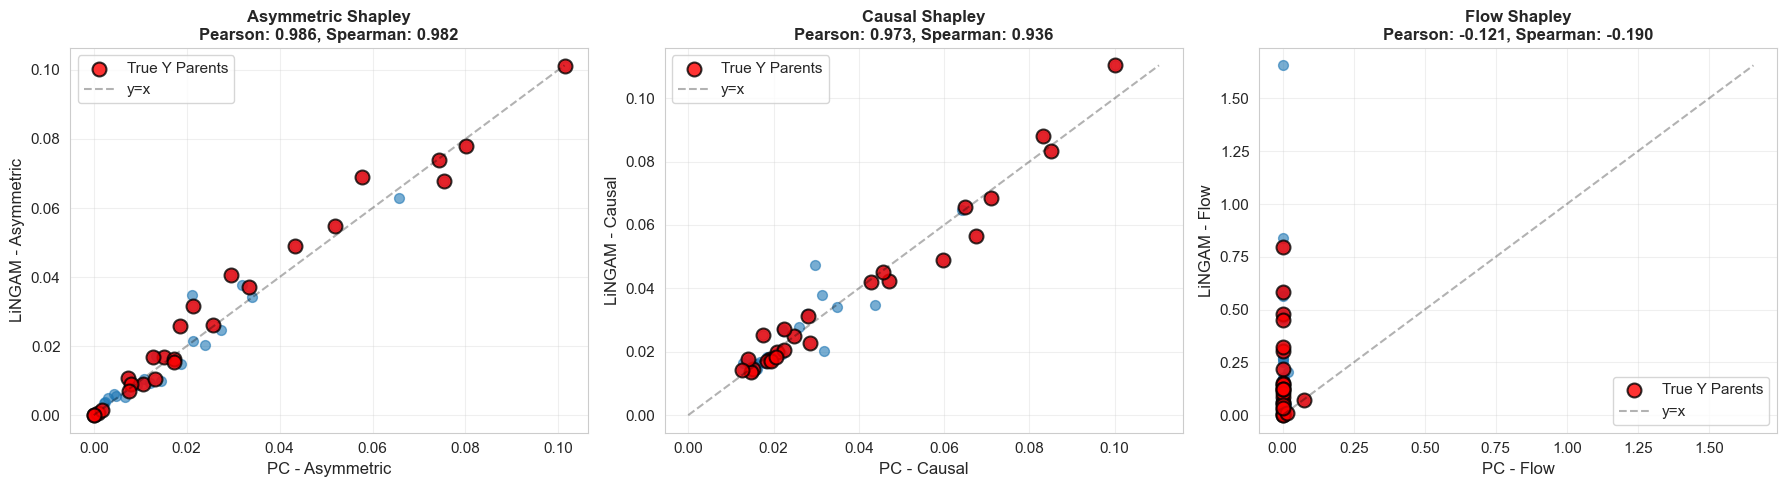

In [18]:
# Compare PC vs LiNGAM for each causal method
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparisons = [
    ('Asymmetric', pc_asym_importance, lingam_asym_importance),
    ('Causal', pc_causal_importance, lingam_causal_importance),
    ('Flow', pc_flow_importance, lingam_flow_importance)
]

for ax, (method_name, pc_imp, lingam_imp) in zip(axes, comparisons):
    # Scatter plot
    ax.scatter(pc_imp, lingam_imp, alpha=0.6, s=50)
    
    # Highlight true parents
    true_parent_mask = [i in true_parents for i in range(len(pc_imp))]
    ax.scatter(pc_imp[true_parent_mask], lingam_imp[true_parent_mask], 
               alpha=0.8, s=100, c='red', label='True Y Parents', edgecolors='black', linewidths=1.5)
    
    # Add diagonal line
    max_val = max(pc_imp.max(), lingam_imp.max())
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='y=x')
    
    # Calculate correlation
    pearson_corr, _ = pearsonr(pc_imp, lingam_imp)
    spearman_corr, _ = spearmanr(pc_imp, lingam_imp)
    
    ax.set_xlabel(f'PC - {method_name}', fontsize=12)
    ax.set_ylabel(f'LiNGAM - {method_name}', fontsize=12)
    ax.set_title(f'{method_name} Shapley\nPearson: {pearson_corr:.3f}, Spearman: {spearman_corr:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Distribution Comparison

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/3310441468.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([non_parent_importance, parent_importance],
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/3310441468.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([non_parent_importance, parent_importance],
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/3310441468.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([non_parent_importance, parent_importance],
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel

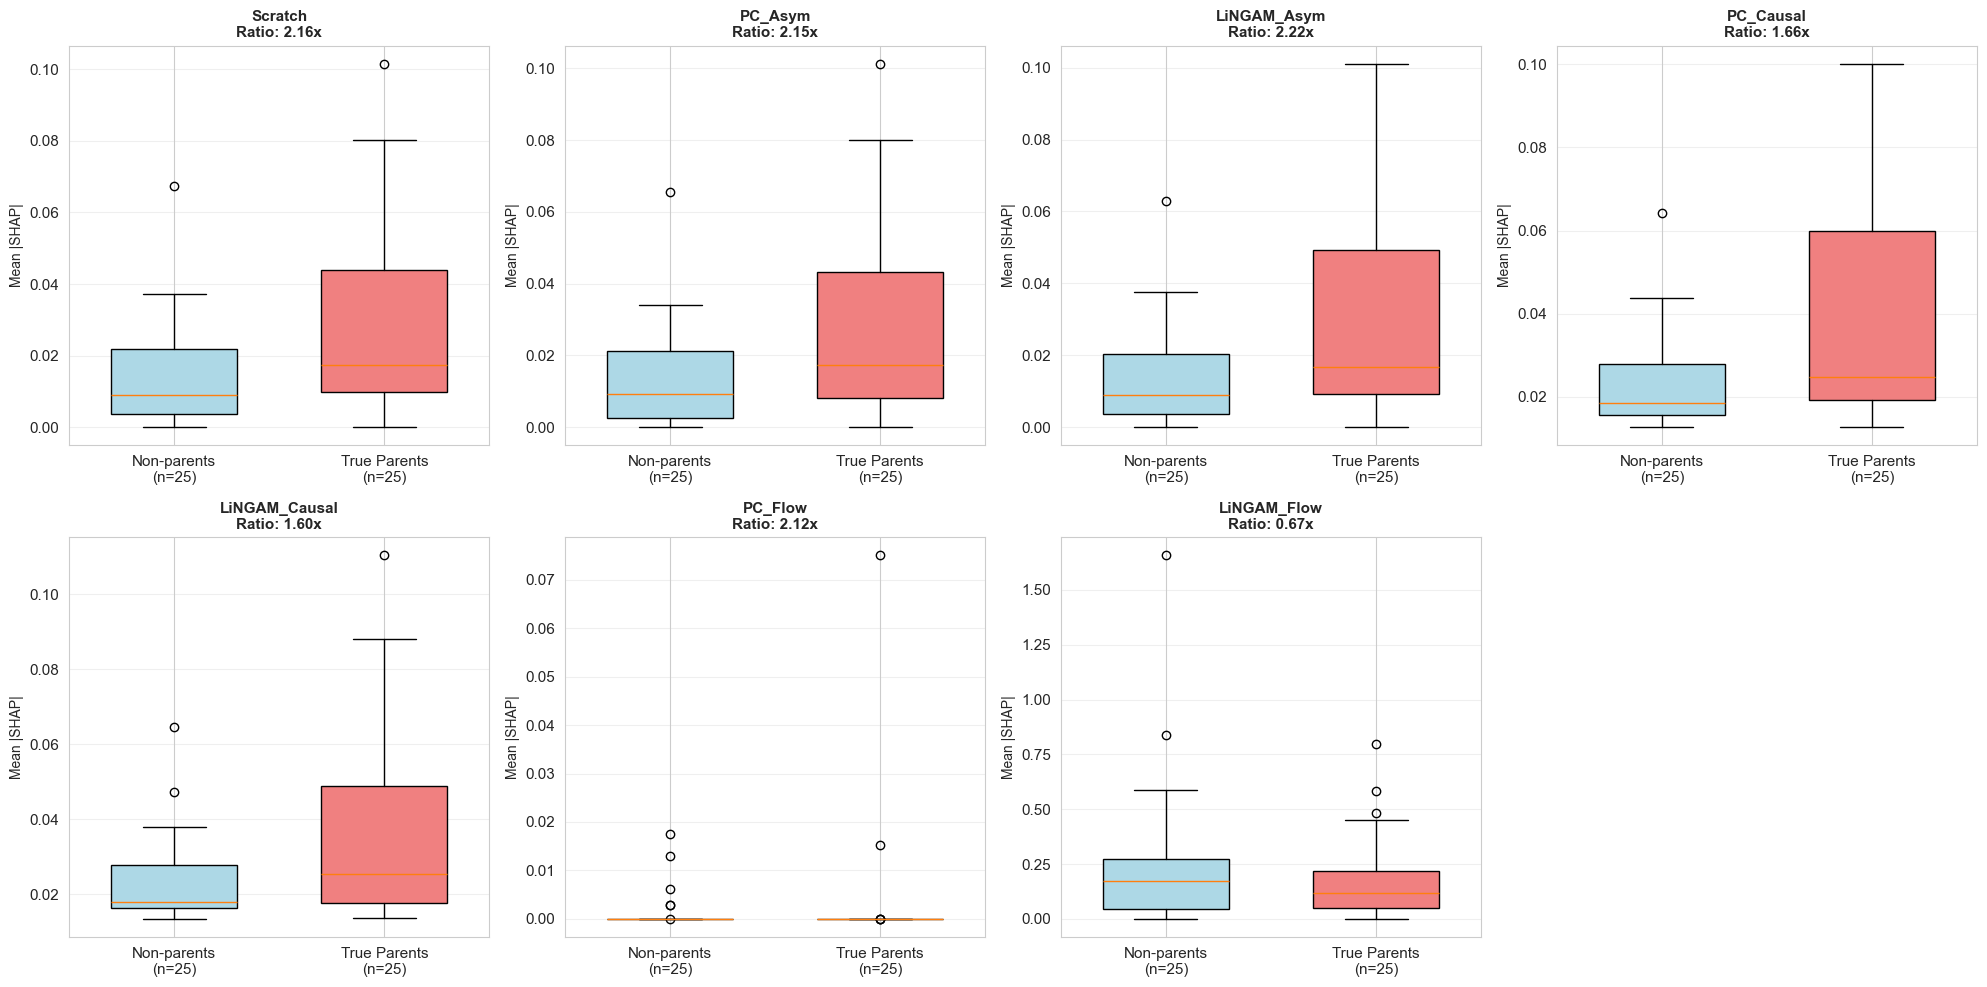

Ratio = Mean SHAP (True Parents) / Mean SHAP (Non-Parents)
Higher ratio = Better separation between parents and non-parents


In [19]:
# Compare distributions of SHAP values for true parents vs non-parents
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

all_methods = [
    ('Scratch', scratch_importance),
    ('PC_Asym', pc_asym_importance),
    ('LiNGAM_Asym', lingam_asym_importance),
    ('PC_Causal', pc_causal_importance),
    ('LiNGAM_Causal', lingam_causal_importance),
    ('PC_Flow', pc_flow_importance),
    ('LiNGAM_Flow', lingam_flow_importance),
]

for idx, (method_name, importance) in enumerate(all_methods):
    ax = axes[idx // 4, idx % 4]
    
    # Separate true parents and non-parents
    parent_importance = importance[list(true_parents)]
    non_parent_importance = importance[[i for i in range(len(importance)) if i not in true_parents]]
    
    # Box plot
    bp = ax.boxplot([non_parent_importance, parent_importance], 
                     labels=['Non-parents\n(n=25)', 'True Parents\n(n=25)'],
                     patch_artist=True, widths=0.6)
    
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    # Calculate means
    mean_non_parent = non_parent_importance.mean()
    mean_parent = parent_importance.mean()
    ratio = mean_parent / mean_non_parent if mean_non_parent > 0 else float('inf')
    
    ax.set_title(f'{method_name}\nRatio: {ratio:.2f}x', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean |SHAP|', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

# Hide the last subplot (we have 7 methods, 8 slots)
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

print("Ratio = Mean SHAP (True Parents) / Mean SHAP (Non-Parents)")
print("Higher ratio = Better separation between parents and non-parents")

## 8. Top-K Agreement Analysis

In [20]:
# Check agreement in top-K features across methods
k_values = [5, 10, 15, 20, 25]

agreement_data = []

for k in k_values:
    # Get top-k for each method
    top_k_scratch = set(np.argsort(scratch_importance)[-k:])
    top_k_pc_asym = set(np.argsort(pc_asym_importance)[-k:])
    top_k_pc_causal = set(np.argsort(pc_causal_importance)[-k:])
    top_k_pc_flow = set(np.argsort(pc_flow_importance)[-k:])
    top_k_lingam_asym = set(np.argsort(lingam_asym_importance)[-k:])
    top_k_lingam_causal = set(np.argsort(lingam_causal_importance)[-k:])
    top_k_lingam_flow = set(np.argsort(lingam_flow_importance)[-k:])
    
    # Calculate overlaps
    agreement_data.append({
        'K': k,
            'Scratch ∩ PC_Asym': len(top_k_scratch & top_k_pc_asym),
            'Scratch ∩ LiNGAM_Asym': len(top_k_scratch & top_k_lingam_asym),
            'PC_Asym ∩ LiNGAM_Asym': len(top_k_pc_asym & top_k_lingam_asym),
        'PC_Flow ∩ LiNGAM_Flow': len(top_k_pc_flow & top_k_lingam_flow),
        'All PC methods': len(top_k_pc_asym & top_k_pc_causal & top_k_pc_flow),
        'All LiNGAM methods': len(top_k_lingam_asym & top_k_lingam_causal & top_k_lingam_flow),
        'True parents in Scratch': len(top_k_scratch & true_parents),
        'True parents in PC_Flow': len(top_k_pc_flow & true_parents),
        'True parents in LiNGAM_Flow': len(top_k_lingam_flow & true_parents),
    })

agreement_df = pd.DataFrame(agreement_data)
print("Top-K Agreement Analysis:")
print("="*80)
print(agreement_df.to_string(index=False))

Top-K Agreement Analysis:
 K  Scratch ∩ PC_Asym  Scratch ∩ LiNGAM_Asym  PC_Asym ∩ LiNGAM_Asym  PC_Flow ∩ LiNGAM_Flow  All PC methods  All LiNGAM methods  True parents in Scratch  True parents in PC_Flow  True parents in LiNGAM_Flow
 5                  4                      5                      4                      0               0                   0                        5                        2                            2
10                  9                      9                      8                      0               2                   1                        9                        5                            4
15                 13                     14                     13                      1               3                   2                       10                        8                            6
20                 20                     19                     19                      6               6                   7                       1

## 9. Feature Ranking Comparison

In [21]:
# Create ranking comparison for top 20 features
top_20_indices = np.argsort(scratch_importance)[-20:][::-1]

ranking_data = []
for idx in top_20_indices:
    fname = feature_names[idx]
    
    # Get ranks (1 = highest importance)
    rank_scratch = len(scratch_importance) - np.where(np.argsort(scratch_importance)[::-1] == idx)[0][0]
    rank_pc_flow = len(pc_flow_importance) - np.where(np.argsort(pc_flow_importance)[::-1] == idx)[0][0]
    rank_lingam_flow = len(lingam_flow_importance) - np.where(np.argsort(lingam_flow_importance)[::-1] == idx)[0][0]
    
    ranking_data.append({
        'Feature': fname,
        'Index': idx,
        'True Parent': '✓' if idx in true_parents else '',
        'Scratch_Rank': rank_scratch,
        'PC_Flow_Rank': rank_pc_flow,
        'LiNGAM_Flow_Rank': rank_lingam_flow,
        'Rank_Diff_PC': abs(rank_scratch - rank_pc_flow),
        'Rank_Diff_LiNGAM': abs(rank_scratch - rank_lingam_flow),
    })

ranking_df = pd.DataFrame(ranking_data)
print("\nTop 20 Features - Ranking Comparison:")
print("="*80)
print(ranking_df.to_string(index=False))


Top 20 Features - Ranking Comparison:
Feature  Index True Parent  Scratch_Rank  PC_Flow_Rank  LiNGAM_Flow_Rank  Rank_Diff_PC  Rank_Diff_LiNGAM
     X3      3           ✓            50            29                39            21                11
    X45     45           ✓            49            17                26            32                23
    X49     49           ✓            48            22                11            26                37
    X11     11           ✓            47            26                20            21                27
    X30     30           ✓            46            50                18             4                28
    X43     43                        45            15                12            30                33
    X40     40           ✓            44            12                46            32                 2
    X46     46           ✓            43            18                 2            25                41
     X8      8  

## 10. Summary Statistics

In [22]:
# Summary of key findings
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\n1. DATASET:")
print(f"   - Name: {DATASET}")
print(f"   - Features: {metadata['n_features']}")
print(f"   - True Y parents: {len(true_parents)}")

print("\n2. TOP-10 FEATURES (by Scratch):")
print(f"   - True parents captured: {n_true_parents_in_top10}/10")
print(f"   - Features: {', '.join(top_10_features)}")

print("\n3. METHOD AGREEMENT (Top-10 overlap):")
k = 10
top_10_scratch = set(np.argsort(scratch_importance)[-k:])
top_10_pc_flow = set(np.argsort(pc_flow_importance)[-k:])
top_10_lingam_flow = set(np.argsort(lingam_flow_importance)[-k:])

print(f"   - Scratch ∩ PC_Flow: {len(top_10_scratch & top_10_pc_flow)}/10")
print(f"   - Scratch ∩ LiNGAM_Flow: {len(top_10_scratch & top_10_lingam_flow)}/10")
print(f"   - PC_Flow ∩ LiNGAM_Flow: {len(top_10_pc_flow & top_10_lingam_flow)}/10")

print("\n4. CORRELATION WITH SCRATCH:")
for method_name, importance in [('PC_Flow', pc_flow_importance), ('LiNGAM_Flow', lingam_flow_importance)]:
    pearson, _ = pearsonr(scratch_importance, importance)
    spearman, _ = spearmanr(scratch_importance, importance)
    print(f"   - {method_name}: Pearson={pearson:.3f}, Spearman={spearman:.3f}")

print("\n5. TRUE PARENT DETECTION (Mean SHAP ratio):")
for method_name, importance in all_methods:
    parent_imp = importance[list(true_parents)]
    non_parent_imp = importance[[i for i in range(len(importance)) if i not in true_parents]]
    ratio = parent_imp.mean() / non_parent_imp.mean() if non_parent_imp.mean() > 0 else float('inf')
    print(f"   - {method_name}: {ratio:.2f}x")

print("\n" + "="*80)

SUMMARY STATISTICS

1. DATASET:
   - Name: mixed_no_conf_f50_s1000_p50
   - Features: 50
   - True Y parents: 25

2. TOP-10 FEATURES (by Scratch):
   - True parents captured: 4/10
   - Features: X3, X45, X49, X11, X30, X43, X40, X46, X8, X22

3. METHOD AGREEMENT (Top-10 overlap):
   - Scratch ∩ PC_Flow: 2/10
   - Scratch ∩ LiNGAM_Flow: 1/10
   - PC_Flow ∩ LiNGAM_Flow: 0/10

4. CORRELATION WITH SCRATCH:
   - PC_Flow: Pearson=0.235, Spearman=-0.096
   - LiNGAM_Flow: Pearson=-0.015, Spearman=0.015

5. TRUE PARENT DETECTION (Mean SHAP ratio):
   - Scratch: 2.16x
   - PC_Asym: 2.15x
   - LiNGAM_Asym: 2.22x
   - PC_Causal: 1.66x
   - LiNGAM_Causal: 1.60x
   - PC_Flow: 2.12x
   - LiNGAM_Flow: 0.67x



## 11. Detailed SHAP Plots: Top 10 Features

For each of the top 10 features, we visualize the distribution of SHAP values across test instances, comparing PC vs LiNGAM for each explainability method.

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(pc_vals, lingam_vals)
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:85: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


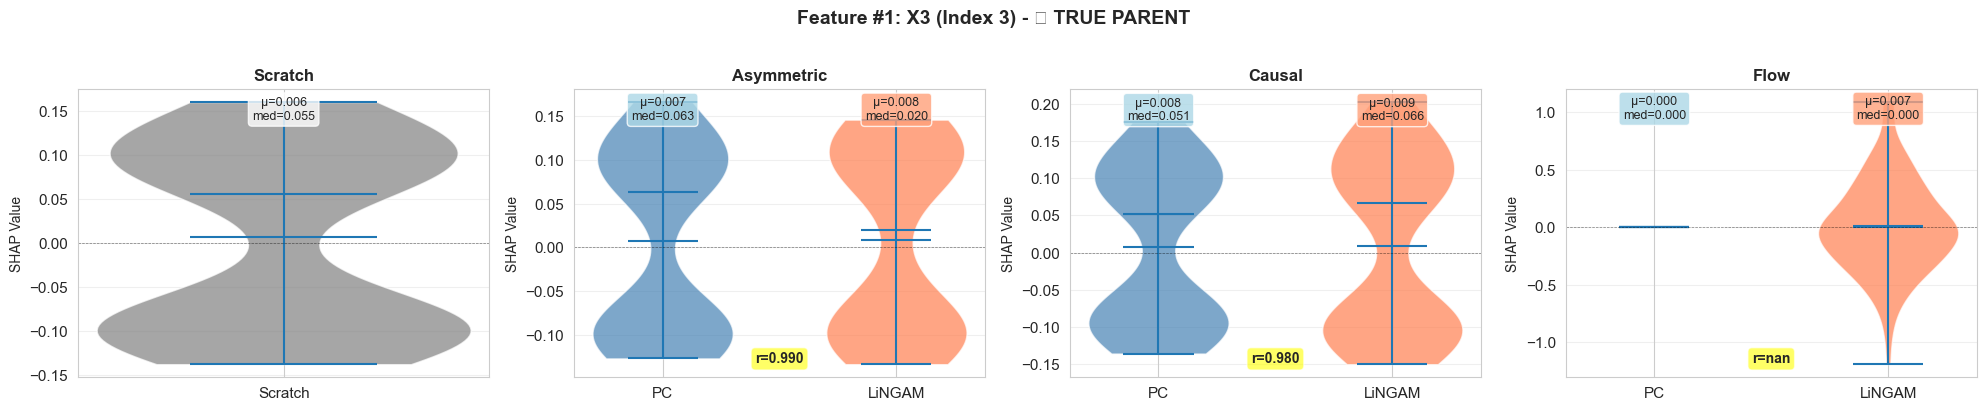

Feature X3: Distribution of SHAP values across 100 test instances
--------------------------------------------------------------------------------


/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(pc_vals, lingam_vals)
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:85: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


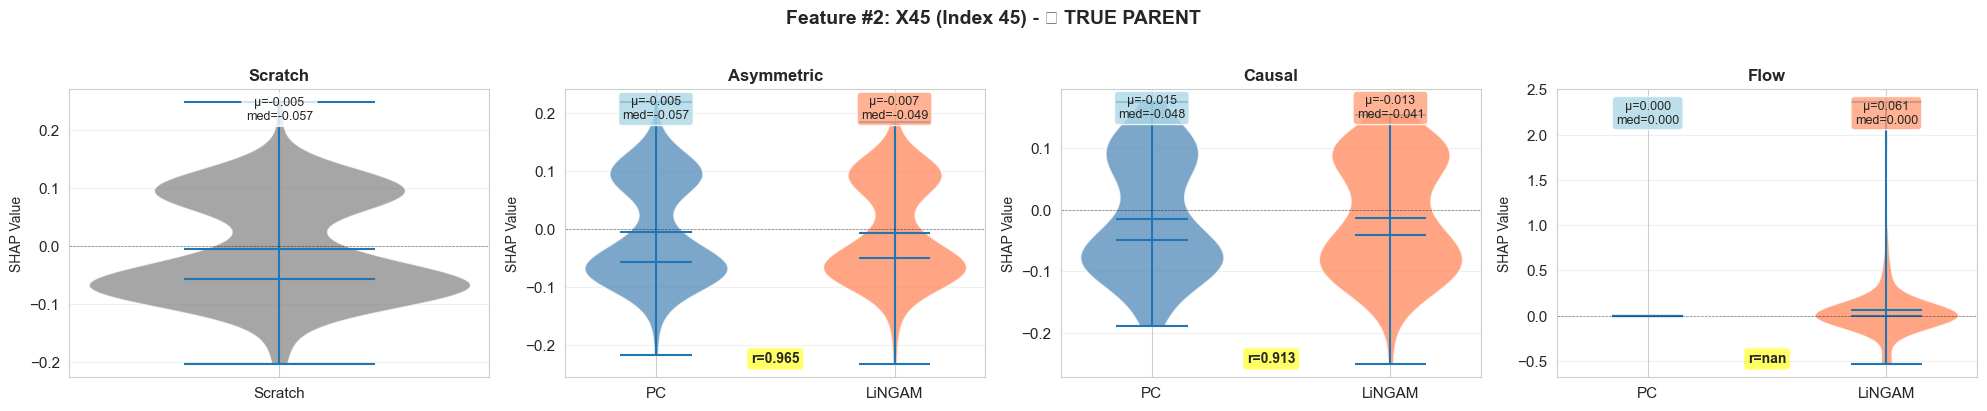

Feature X45: Distribution of SHAP values across 100 test instances
--------------------------------------------------------------------------------


/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(pc_vals, lingam_vals)
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:85: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


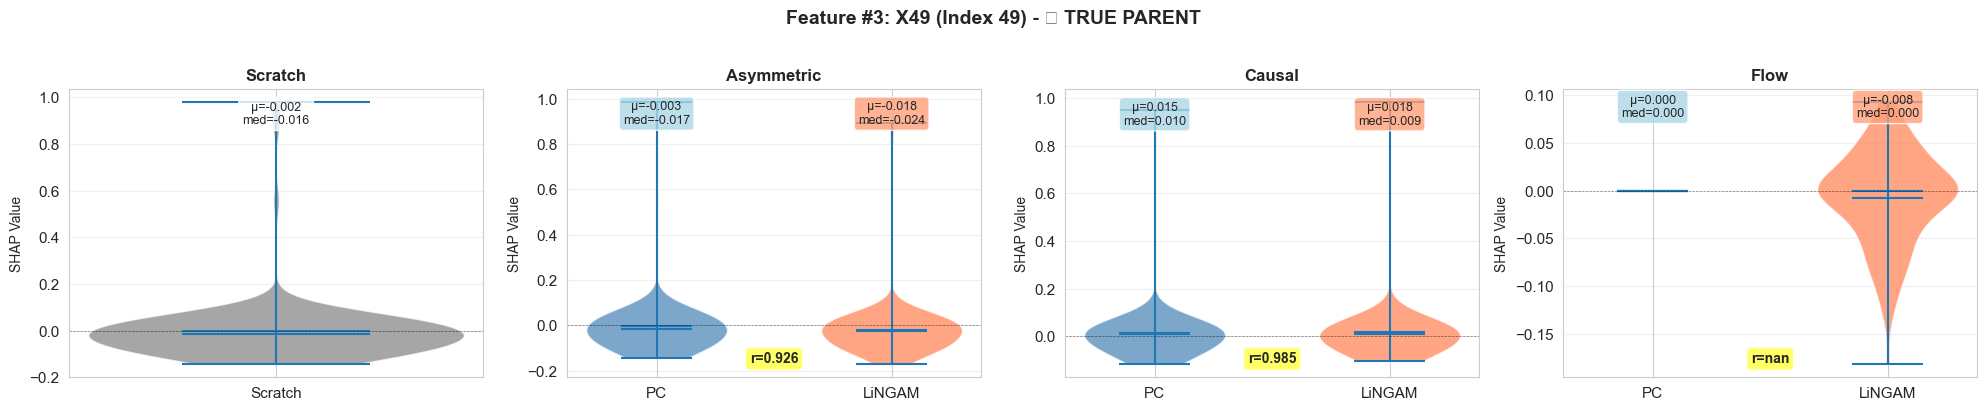

Feature X49: Distribution of SHAP values across 100 test instances
--------------------------------------------------------------------------------


/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(pc_vals, lingam_vals)
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:85: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


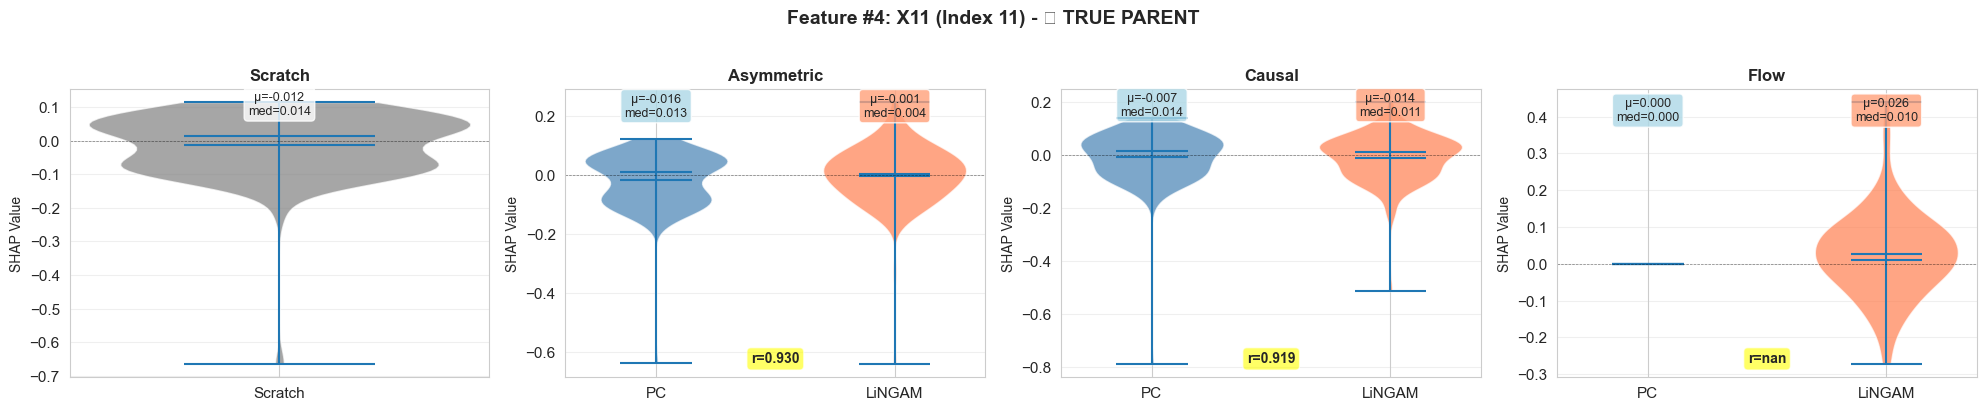

Feature X11: Distribution of SHAP values across 100 test instances
--------------------------------------------------------------------------------


/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:85: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


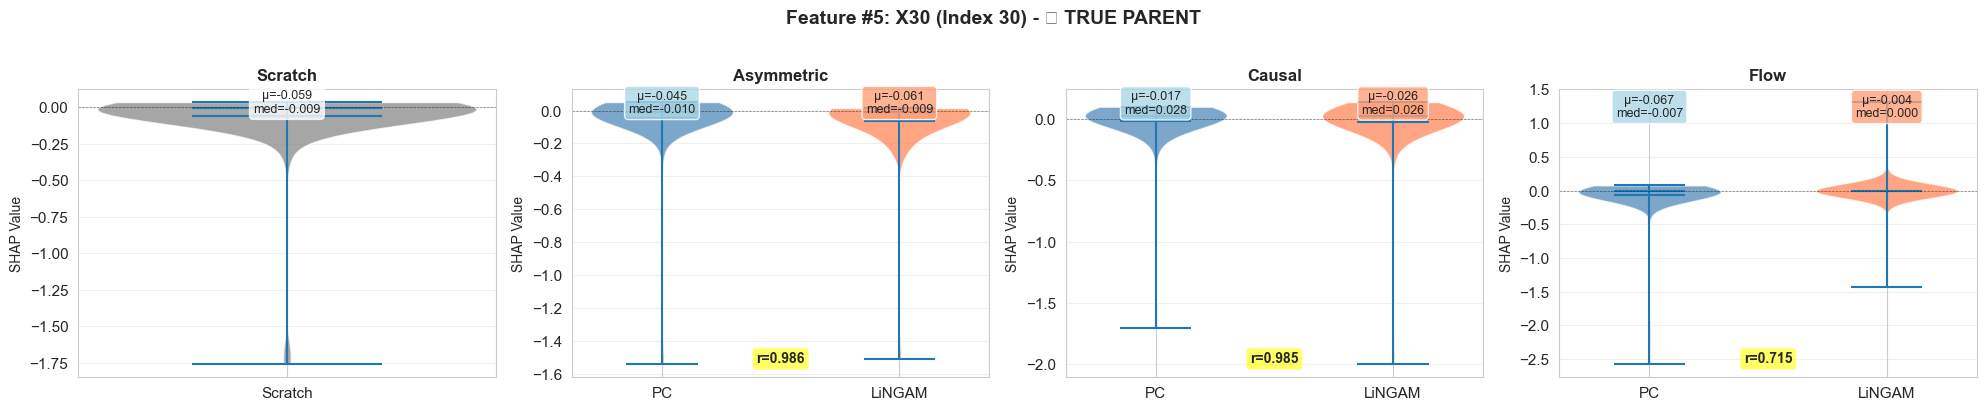

Feature X30: Distribution of SHAP values across 100 test instances
--------------------------------------------------------------------------------


/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(pc_vals, lingam_vals)


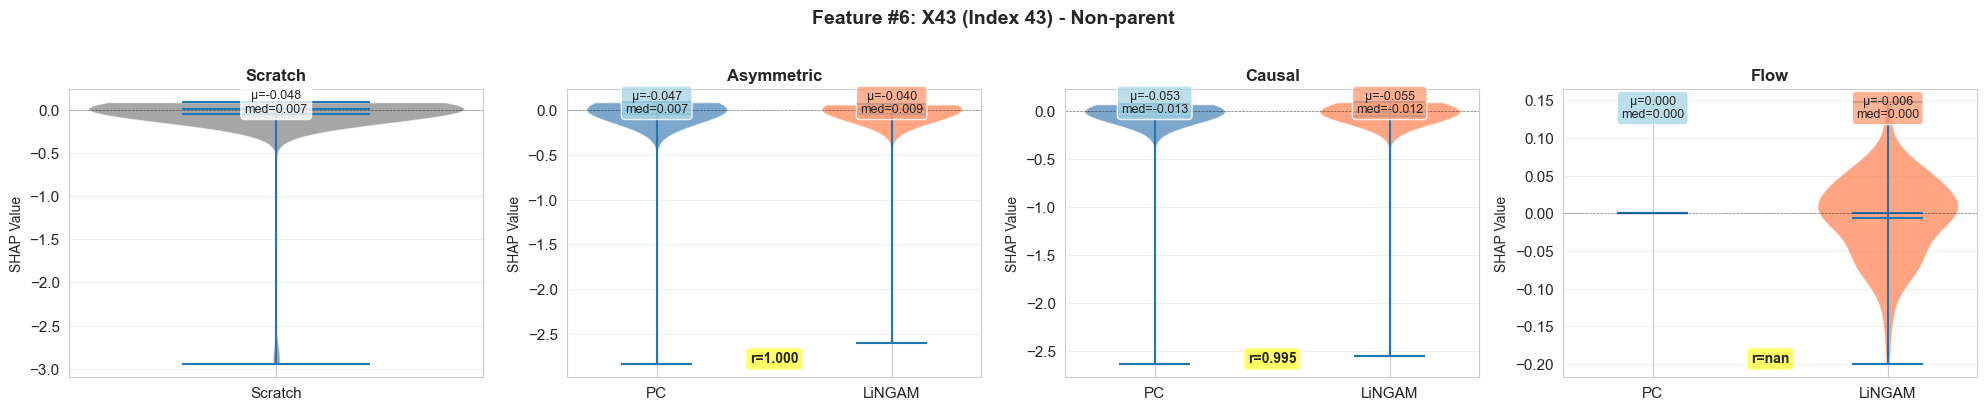

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(pc_vals, lingam_vals)
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:85: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()


Feature X43: Distribution of SHAP values across 100 test instances
--------------------------------------------------------------------------------


/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


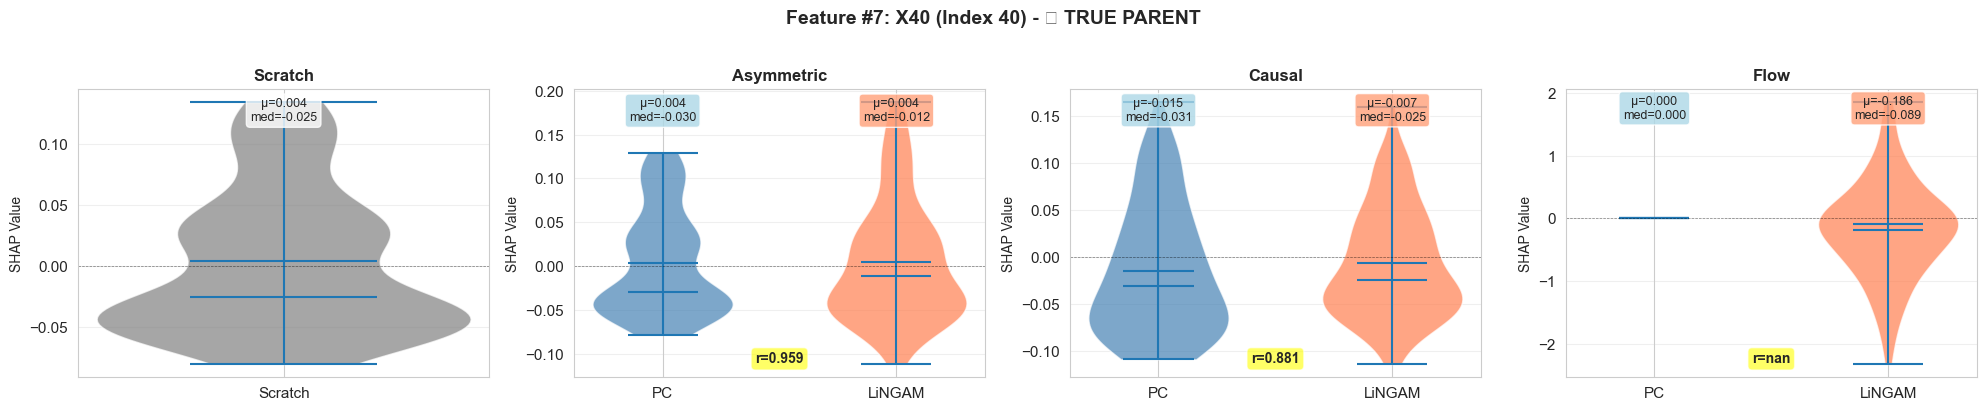

Feature X40: Distribution of SHAP values across 100 test instances
--------------------------------------------------------------------------------


/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(pc_vals, lingam_vals)
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:85: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


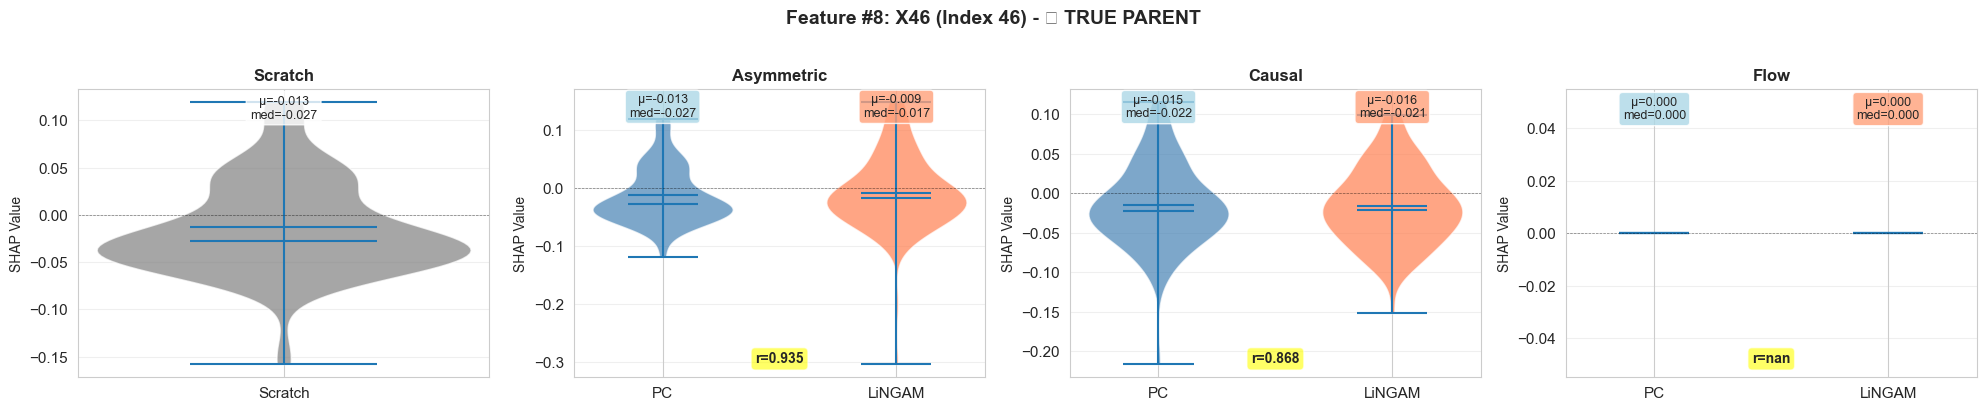

Feature X46: Distribution of SHAP values across 100 test instances
--------------------------------------------------------------------------------


/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:85: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


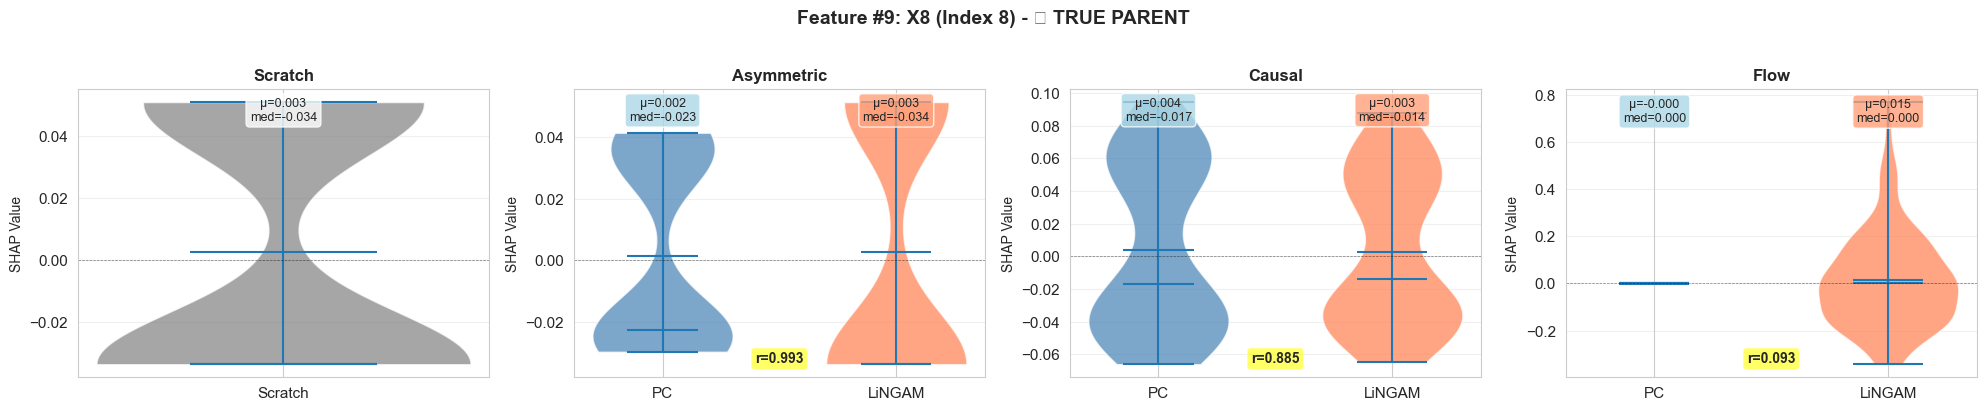

Feature X8: Distribution of SHAP values across 100 test instances
--------------------------------------------------------------------------------


/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1433627308.py:85: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


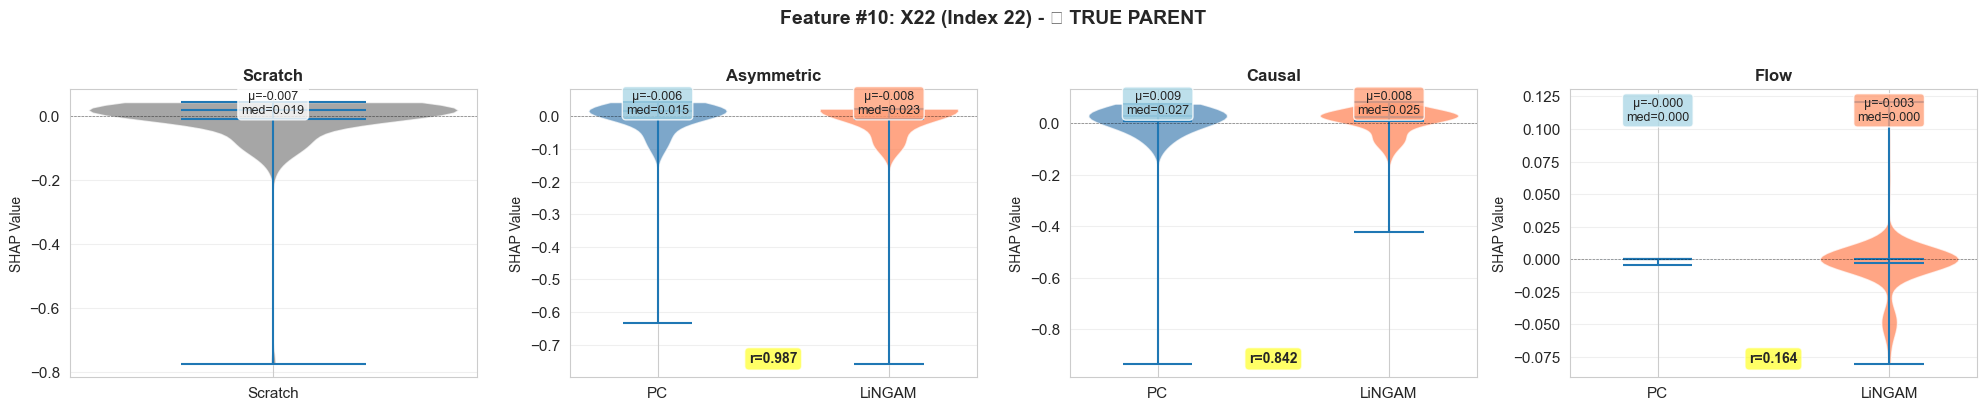

Feature X22: Distribution of SHAP values across 100 test instances
--------------------------------------------------------------------------------


In [23]:
# Create detailed SHAP plots for each top 10 feature
from matplotlib.patches import Rectangle

for feature_idx, (idx, fname) in enumerate(zip(top_10_indices, top_10_features), 1):
    is_true_parent = idx in true_parents
    
    # Create figure with 4 subplots (Scratch, Asymmetric, Causal, Flow)
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    
    # Data for this feature across all instances
    feature_data = [
        ('Scratch', scratch_values[:, idx], scratch_values[:, idx], 'gray'),  # Same for both PC/LiNGAM
        ('Asymmetric', pc_asym_values[:, idx], lingam_asym_values[:, idx], 'blue'),
        ('Causal', pc_causal_values[:, idx], lingam_causal_values[:, idx], 'green'),
        ('Flow', pc_flow_values[:, idx], lingam_flow_values[:, idx], 'orange'),
    ]
    
    for ax_idx, (method_name, pc_vals, lingam_vals, color) in enumerate(feature_data):
        ax = axes[ax_idx]
        
        if method_name == 'Scratch':
            # For Scratch, only one distribution (no PC/LiNGAM distinction)
            parts = ax.violinplot([pc_vals], positions=[0], widths=0.7, 
                                   showmeans=True, showmedians=True)
            for pc in parts['bodies']:
                pc.set_facecolor(color)
                pc.set_alpha(0.7)
            
            ax.set_xticks([0])
            ax.set_xticklabels(['Scratch'])
            
            # Add statistics
            mean_val = pc_vals.mean()
            median_val = np.median(pc_vals)
            ax.text(0, ax.get_ylim()[1] * 0.95, 
                   f'μ={mean_val:.3f}\nmed={median_val:.3f}',
                   ha='center', va='top', fontsize=9, 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            # For other methods, show PC vs LiNGAM
            positions = [0, 1]
            parts = ax.violinplot([pc_vals, lingam_vals], positions=positions, 
                                  widths=0.6, showmeans=True, showmedians=True)
            
            # Color PC and LiNGAM differently
            parts['bodies'][0].set_facecolor('steelblue')
            parts['bodies'][0].set_alpha(0.7)
            parts['bodies'][1].set_facecolor('coral')
            parts['bodies'][1].set_alpha(0.7)
            
            ax.set_xticks(positions)
            ax.set_xticklabels(['PC', 'LiNGAM'])
            
            # Add statistics for both
            mean_pc = pc_vals.mean()
            mean_lingam = lingam_vals.mean()
            median_pc = np.median(pc_vals)
            median_lingam = np.median(lingam_vals)
            
            ax.text(0, ax.get_ylim()[1] * 0.95, 
                   f'μ={mean_pc:.3f}\nmed={median_pc:.3f}',
                   ha='center', va='top', fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
            ax.text(1, ax.get_ylim()[1] * 0.95, 
                   f'μ={mean_lingam:.3f}\nmed={median_lingam:.3f}',
                   ha='center', va='top', fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.8))
            
            # Calculate correlation between PC and LiNGAM
            corr, _ = pearsonr(pc_vals, lingam_vals)
            ax.text(0.5, ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05,
                   f'r={corr:.3f}', ha='center', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))
        
        ax.set_title(f'{method_name}', fontsize=12, fontweight='bold')
        ax.set_ylabel('SHAP Value', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Main title
    parent_status = "✓ TRUE PARENT" if is_true_parent else "Non-parent"
    fig.suptitle(f'Feature #{feature_idx}: {fname} (Index {idx}) - {parent_status}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Feature {fname}: Distribution of SHAP values across {len(pc_vals)} test instances")
    print("-" * 80)

## 12. Aggregated Comparison: All Methods Side-by-Side

A comprehensive view showing all methods for all top 10 features in one plot.

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1595180425.py:49: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


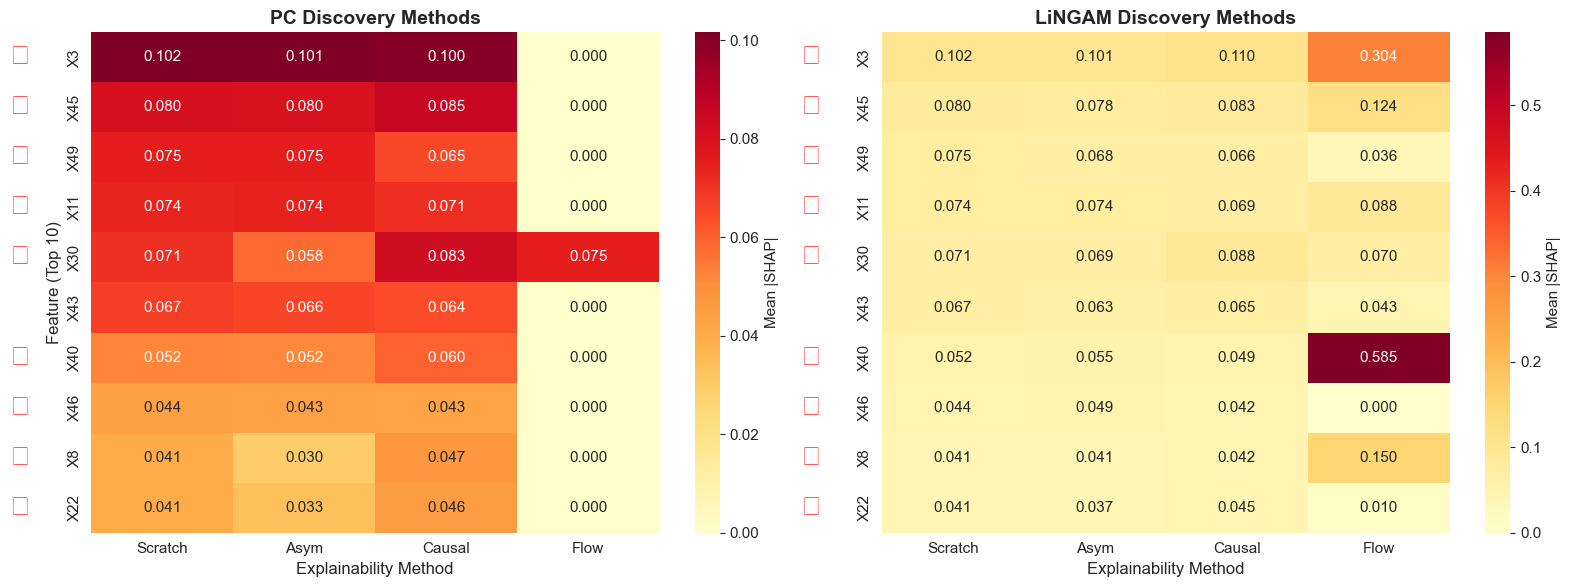

★ = True Y parent

This heatmap shows the mean absolute SHAP value for each feature-method combination.


In [24]:
# Create a comprehensive heatmap showing mean absolute SHAP for top 10 features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for heatmap
methods_list = ['Scratch', 'Asym', 'Causal', 'Flow']
pc_data = []
lingam_data = []

for idx in top_10_indices:
    pc_row = [
        scratch_importance[idx],
        pc_asym_importance[idx],
        pc_causal_importance[idx],
        pc_flow_importance[idx]
    ]
    lingam_row = [
        scratch_importance[idx],
        lingam_asym_importance[idx],
        lingam_causal_importance[idx],
        lingam_flow_importance[idx]
    ]
    pc_data.append(pc_row)
    lingam_data.append(lingam_row)

pc_df = pd.DataFrame(pc_data, columns=methods_list, index=top_10_features)
lingam_df = pd.DataFrame(lingam_data, columns=methods_list, index=top_10_features)

# Plot heatmaps
sns.heatmap(pc_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0], 
            cbar_kws={'label': 'Mean |SHAP|'}, vmin=0)
axes[0].set_title('PC Discovery Methods', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Explainability Method', fontsize=12)
axes[0].set_ylabel('Feature (Top 10)', fontsize=12)

sns.heatmap(lingam_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Mean |SHAP|'}, vmin=0)
axes[1].set_title('LiNGAM Discovery Methods', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Explainability Method', fontsize=12)
axes[1].set_ylabel('')

# Mark true parents
for i, (idx, fname) in enumerate(zip(top_10_indices, top_10_features)):
    if idx in true_parents:
        # Add a star marker for true parents
        for ax in axes:
            ax.text(-0.5, i + 0.5, '★', fontsize=20, color='red', 
                   ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("\nThis heatmap shows the mean absolute SHAP value for each feature-method combination.")

## 13. Instance-Level Comparison

Examine how SHAP values differ across specific test instances for different Shapley methods.

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/2101699375.py:49: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


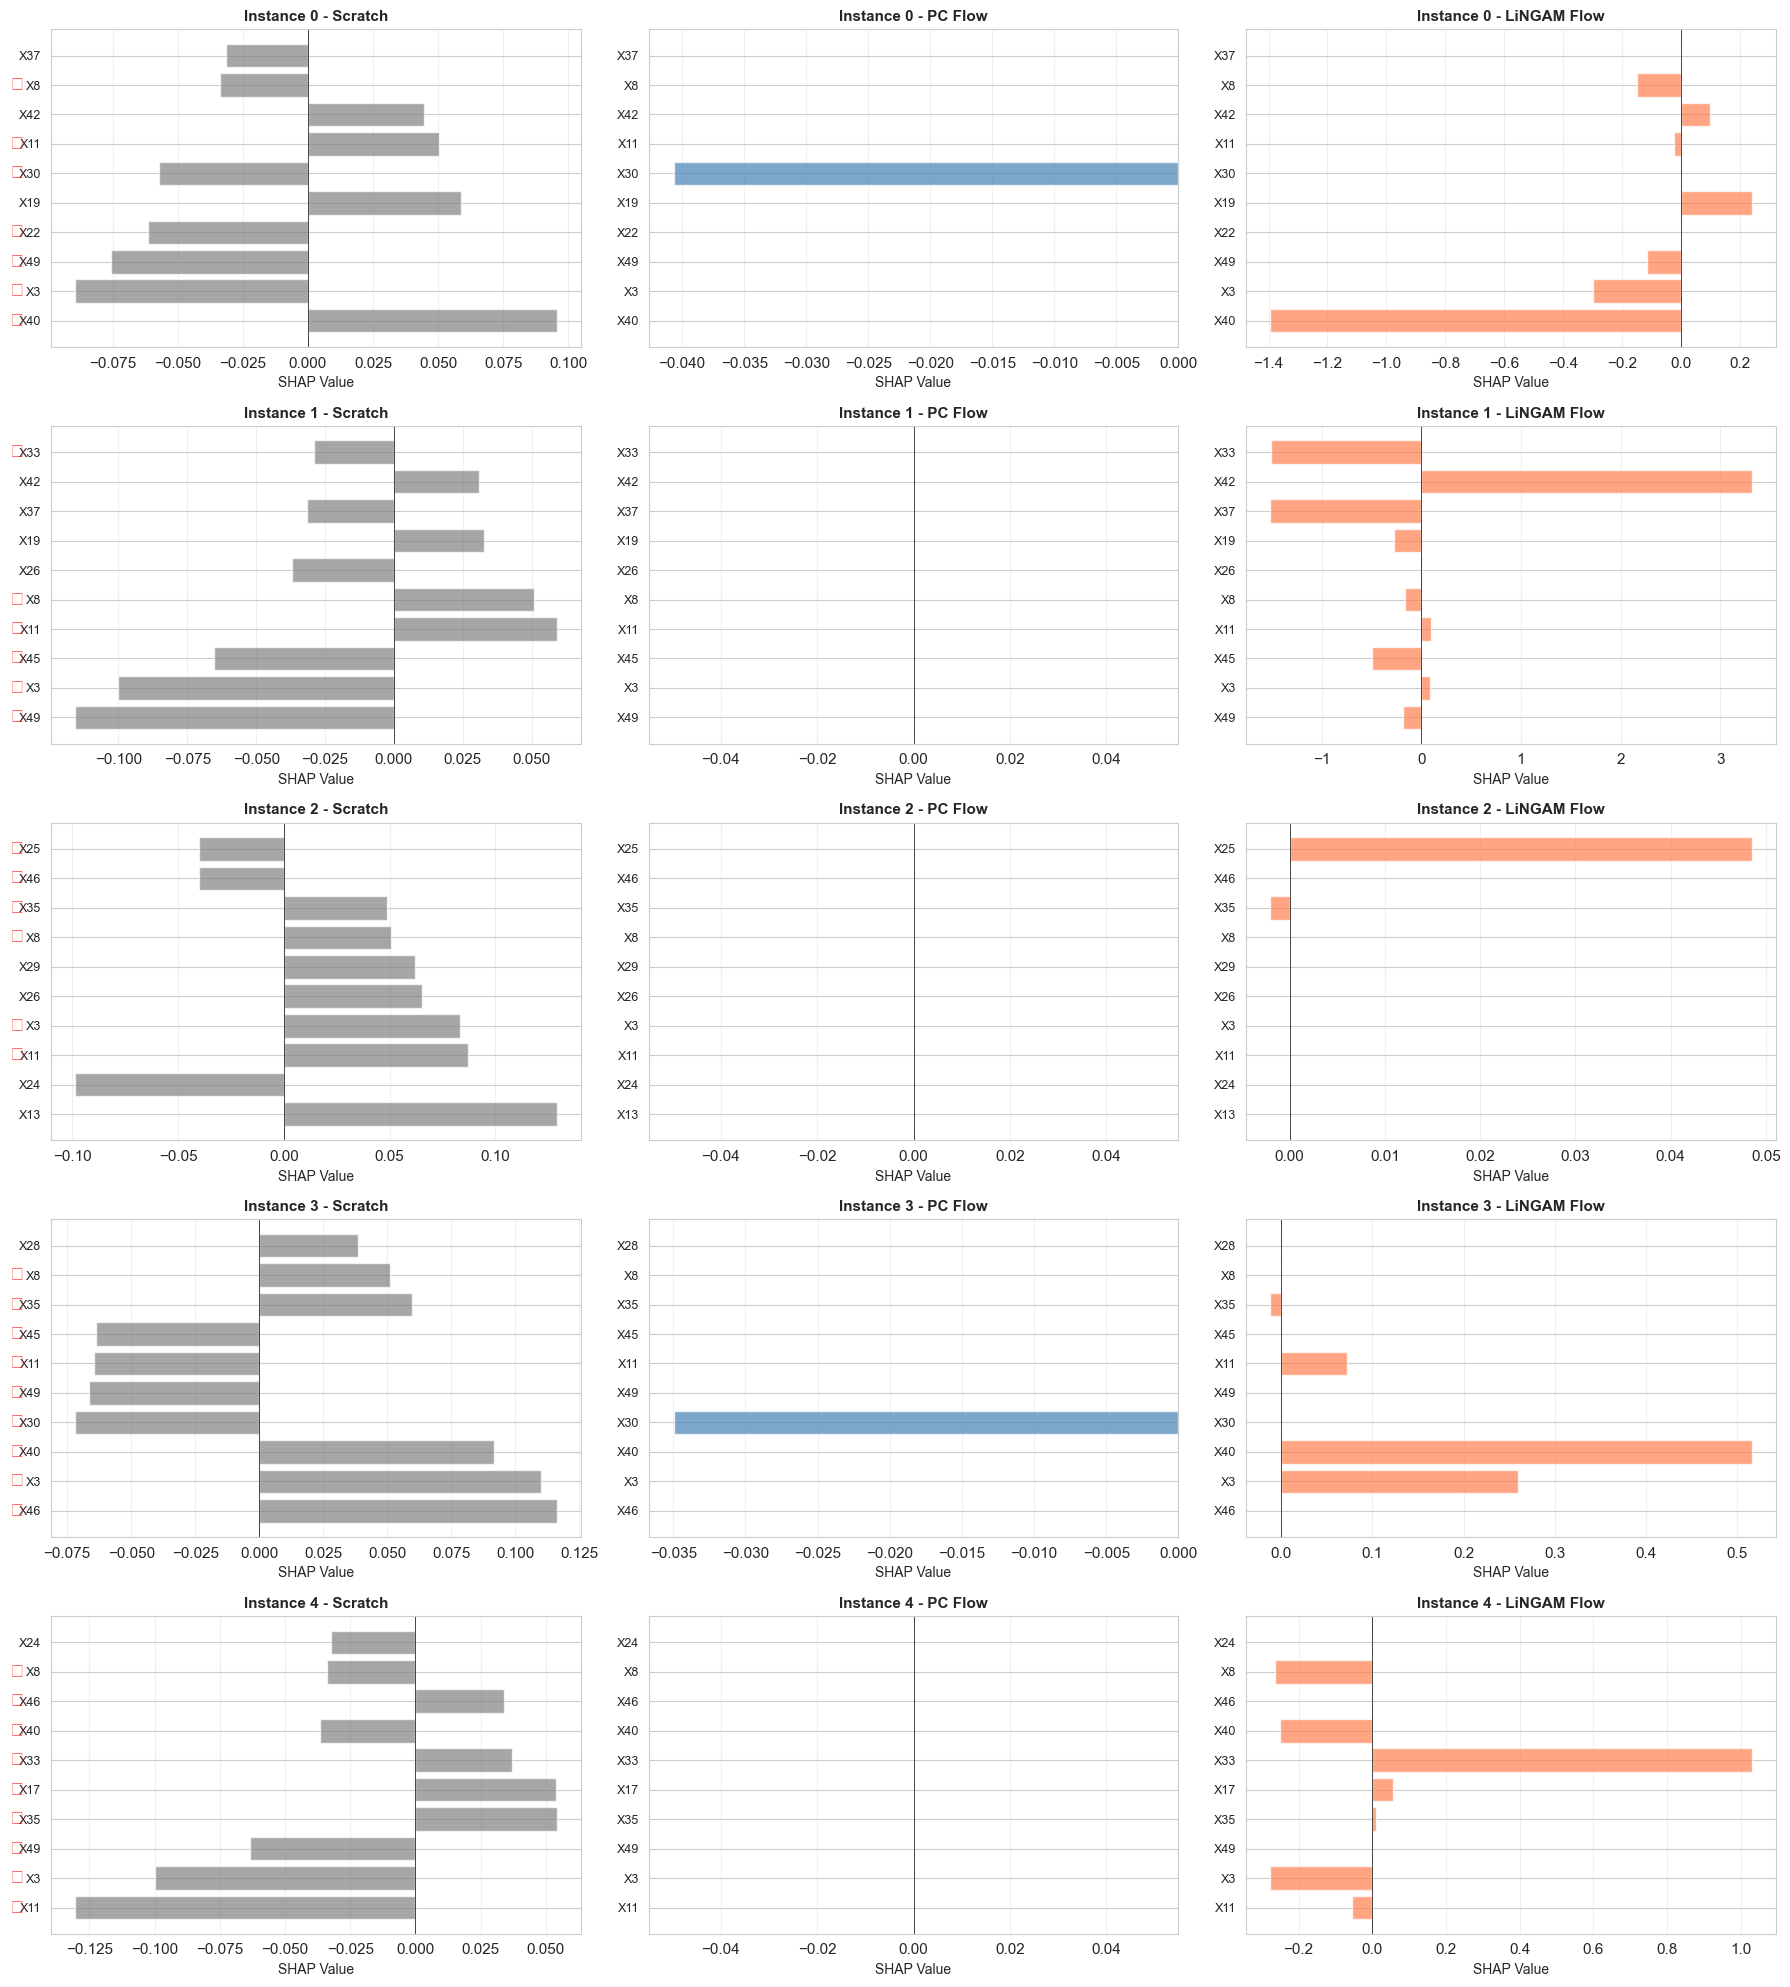

★ = True Y parent

This shows the top 10 features for specific test instances,
revealing how explanations can differ at the instance level.


In [25]:
# Show instance-level comparison for a few interesting cases
n_instances_to_show = 5

fig, axes = plt.subplots(n_instances_to_show, 3, figsize=(18, 4*n_instances_to_show))

for inst_idx in range(n_instances_to_show):
    # Get SHAP values for this instance across all features
    scratch_inst = scratch_values[inst_idx, :]
    pc_flow_inst = pc_flow_values[inst_idx, :]
    lingam_flow_inst = lingam_flow_values[inst_idx, :]
    
    # Get top 10 features for this instance
    top_10_inst = np.argsort(np.abs(scratch_inst))[-10:][::-1]
    top_10_features_inst = [feature_names[i] for i in top_10_inst]
    
    # Plot 1: Scratch values
    axes[inst_idx, 0].barh(range(10), scratch_inst[top_10_inst], color='gray', alpha=0.7)
    axes[inst_idx, 0].set_yticks(range(10))
    axes[inst_idx, 0].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 0].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 0].set_title(f'Instance {inst_idx} - Scratch', fontsize=11, fontweight='bold')
    axes[inst_idx, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 0].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 0].text(-0.05, i, '★', transform=axes[inst_idx, 0].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')
    
    # Plot 2: PC Flow values
    axes[inst_idx, 1].barh(range(10), pc_flow_inst[top_10_inst], color='steelblue', alpha=0.7)
    axes[inst_idx, 1].set_yticks(range(10))
    axes[inst_idx, 1].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 1].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 1].set_title(f'Instance {inst_idx} - PC Flow', fontsize=11, fontweight='bold')
    axes[inst_idx, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 1].grid(True, alpha=0.3, axis='x')
    
    # Plot 3: LiNGAM Flow values
    axes[inst_idx, 2].barh(range(10), lingam_flow_inst[top_10_inst], color='coral', alpha=0.7)
    axes[inst_idx, 2].set_yticks(range(10))
    axes[inst_idx, 2].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 2].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 2].set_title(f'Instance {inst_idx} - LiNGAM Flow', fontsize=11, fontweight='bold')
    axes[inst_idx, 2].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("\nThis shows the top 10 features for specific test instances,")
print("revealing how explanations can differ at the instance level.")

### 13.3 ShapleyFlow: Instance-Level Comparison

Examining how ShapleyFlow values differ across specific test instances for Scratch, PC, and LiNGAM methods.

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1997755101.py:61: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


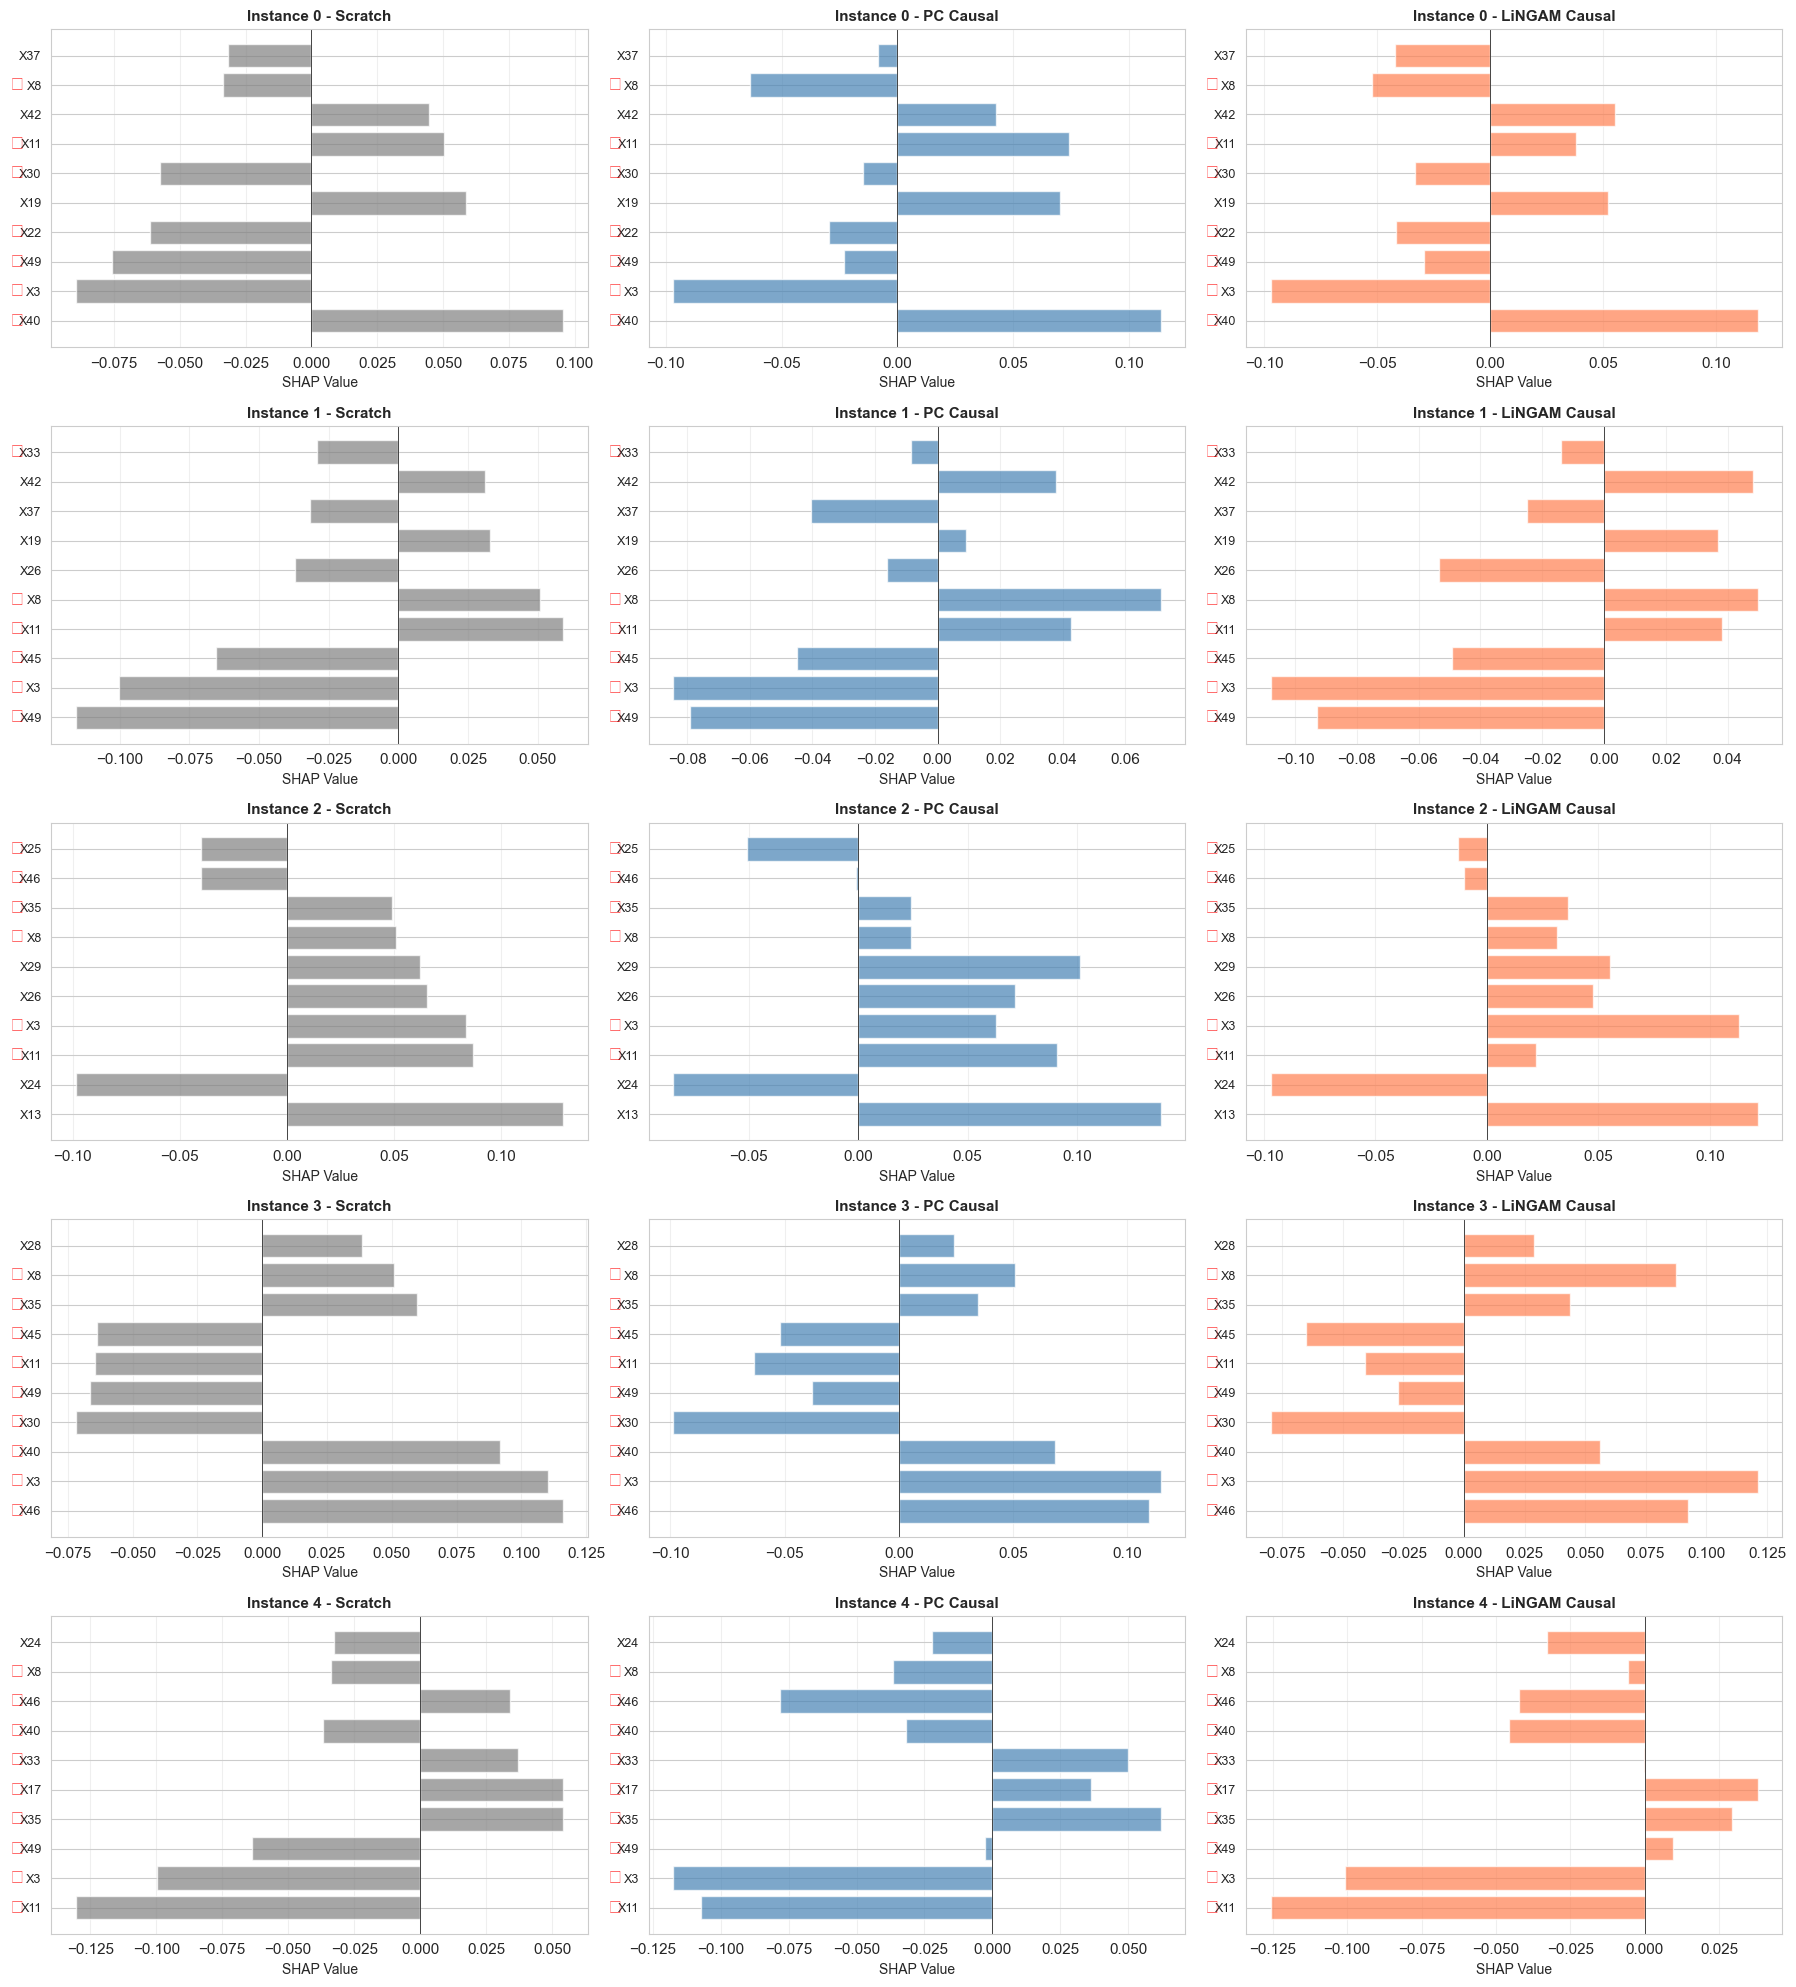

★ = True Y parent

This shows the top 10 features for specific test instances using Causal Shapley,
revealing how explanations can differ at the instance level across methods.


In [26]:
# Show instance-level comparison for Causal Shapley
n_instances_to_show = 5

fig, axes = plt.subplots(n_instances_to_show, 3, figsize=(18, 4*n_instances_to_show))

for inst_idx in range(n_instances_to_show):
    # Get SHAP values for this instance across all features
    scratch_inst = scratch_values[inst_idx, :]
    pc_causal_inst = pc_causal_values[inst_idx, :]
    lingam_causal_inst = lingam_causal_values[inst_idx, :]
    
    # Get top 10 features for this instance
    top_10_inst = np.argsort(np.abs(scratch_inst))[-10:][::-1]
    top_10_features_inst = [feature_names[i] for i in top_10_inst]
    
    # Plot 1: Scratch values
    axes[inst_idx, 0].barh(range(10), scratch_inst[top_10_inst], color='gray', alpha=0.7)
    axes[inst_idx, 0].set_yticks(range(10))
    axes[inst_idx, 0].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 0].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 0].set_title(f'Instance {inst_idx} - Scratch', fontsize=11, fontweight='bold')
    axes[inst_idx, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 0].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 0].text(-0.05, i, '★', transform=axes[inst_idx, 0].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')
    
    # Plot 2: PC Causal values
    axes[inst_idx, 1].barh(range(10), pc_causal_inst[top_10_inst], color='steelblue', alpha=0.7)
    axes[inst_idx, 1].set_yticks(range(10))
    axes[inst_idx, 1].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 1].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 1].set_title(f'Instance {inst_idx} - PC Causal', fontsize=11, fontweight='bold')
    axes[inst_idx, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 1].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 1].text(-0.05, i, '★', transform=axes[inst_idx, 1].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')
    
    # Plot 3: LiNGAM Causal values
    axes[inst_idx, 2].barh(range(10), lingam_causal_inst[top_10_inst], color='coral', alpha=0.7)
    axes[inst_idx, 2].set_yticks(range(10))
    axes[inst_idx, 2].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 2].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 2].set_title(f'Instance {inst_idx} - LiNGAM Causal', fontsize=11, fontweight='bold')
    axes[inst_idx, 2].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 2].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 2].text(-0.05, i, '★', transform=axes[inst_idx, 2].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')

plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("\nThis shows the top 10 features for specific test instances using Causal Shapley,")
print("revealing how explanations can differ at the instance level across methods.")

### 13.2 Causal Shapley: Instance-Level Comparison

Examining how Causal Shapley values differ across specific test instances for Scratch, PC, and LiNGAM methods.

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1014420421.py:61: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


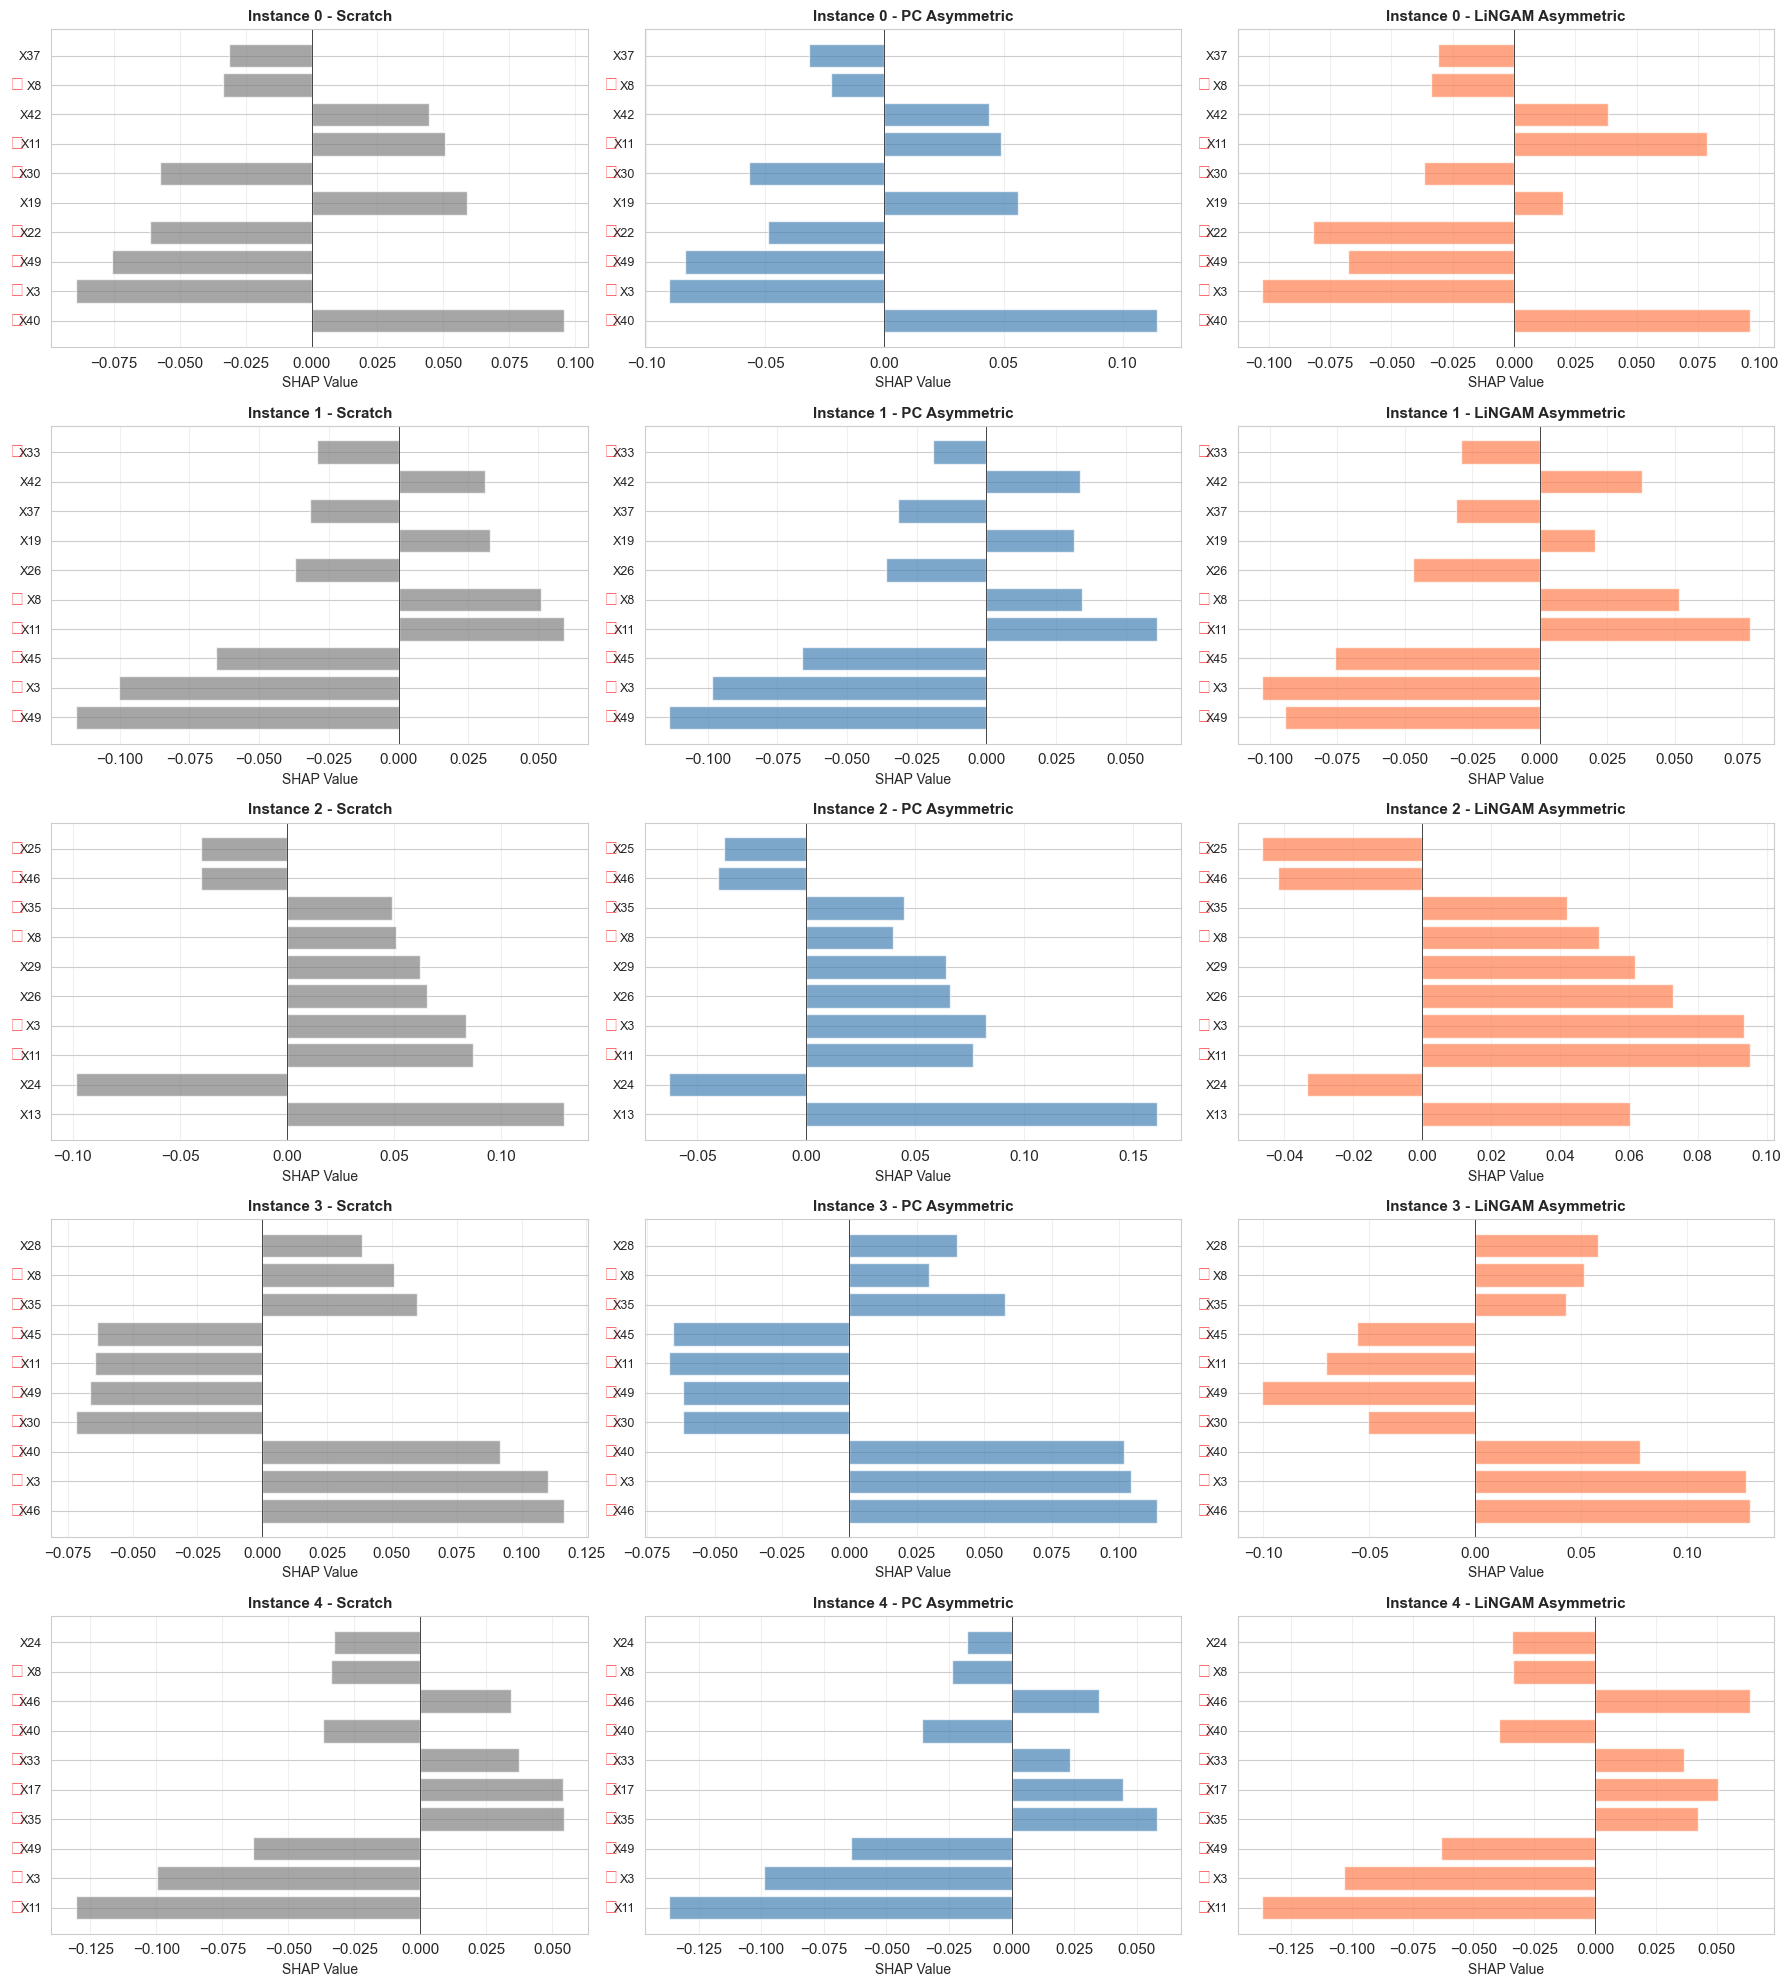

★ = True Y parent

This shows the top 10 features for specific test instances using Asymmetric Shapley,
revealing how explanations can differ at the instance level across methods.


In [27]:
# Show instance-level comparison for Asymmetric Shapley
n_instances_to_show = 5

fig, axes = plt.subplots(n_instances_to_show, 3, figsize=(18, 4*n_instances_to_show))

for inst_idx in range(n_instances_to_show):
    # Get SHAP values for this instance across all features
    scratch_inst = scratch_values[inst_idx, :]
    pc_asym_inst = pc_asym_values[inst_idx, :]
    lingam_asym_inst = lingam_asym_values[inst_idx, :]
    
    # Get top 10 features for this instance
    top_10_inst = np.argsort(np.abs(scratch_inst))[-10:][::-1]
    top_10_features_inst = [feature_names[i] for i in top_10_inst]
    
    # Plot 1: Scratch values
    axes[inst_idx, 0].barh(range(10), scratch_inst[top_10_inst], color='gray', alpha=0.7)
    axes[inst_idx, 0].set_yticks(range(10))
    axes[inst_idx, 0].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 0].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 0].set_title(f'Instance {inst_idx} - Scratch', fontsize=11, fontweight='bold')
    axes[inst_idx, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 0].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 0].text(-0.05, i, '★', transform=axes[inst_idx, 0].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')
    
    # Plot 2: PC Asymmetric values
    axes[inst_idx, 1].barh(range(10), pc_asym_inst[top_10_inst], color='steelblue', alpha=0.7)
    axes[inst_idx, 1].set_yticks(range(10))
    axes[inst_idx, 1].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 1].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 1].set_title(f'Instance {inst_idx} - PC Asymmetric', fontsize=11, fontweight='bold')
    axes[inst_idx, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 1].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 1].text(-0.05, i, '★', transform=axes[inst_idx, 1].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')
    
    # Plot 3: LiNGAM Asymmetric values
    axes[inst_idx, 2].barh(range(10), lingam_asym_inst[top_10_inst], color='coral', alpha=0.7)
    axes[inst_idx, 2].set_yticks(range(10))
    axes[inst_idx, 2].set_yticklabels(top_10_features_inst, fontsize=9)
    axes[inst_idx, 2].set_xlabel('SHAP Value', fontsize=10)
    axes[inst_idx, 2].set_title(f'Instance {inst_idx} - LiNGAM Asymmetric', fontsize=11, fontweight='bold')
    axes[inst_idx, 2].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[inst_idx, 2].grid(True, alpha=0.3, axis='x')
    
    # Mark true parents
    for i, idx in enumerate(top_10_inst):
        if idx in true_parents:
            axes[inst_idx, 2].text(-0.05, i, '★', transform=axes[inst_idx, 2].get_yaxis_transform(),
                                  fontsize=14, color='red', ha='right', va='center')

plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("\nThis shows the top 10 features for specific test instances using Asymmetric Shapley,")
print("revealing how explanations can differ at the instance level across methods.")

### 13.1 Asymmetric Shapley: Instance-Level Comparison

Examining how Asymmetric Shapley values differ across specific test instances for Scratch, PC, and LiNGAM methods.

## Conclusions

Based on the analysis above, we can observe:

1. **Top Feature Identification**: The top 10 features identified by Scratch show varying levels of agreement with causal methods
2. **PC vs LiNGAM**: The correlation and agreement between PC and LiNGAM-based methods varies
3. **Flow Methods**: ShapleyFlow provides a distinct perspective compared to Asymmetric and Causal Shapley
4. **True Parent Detection**: Different methods show different abilities to separate true Y parents from non-parents

Next steps:
- Analyze the causal graphs discovered by PC and LiNGAM
- Investigate why certain features rank differently across methods
- Examine specific instances where methods disagree

## 14. SHAP Dependence Plots: Feature Value vs SHAP Value

For each Shapley method (Asymmetric, Causal, Flow), we create detailed dependence plots showing:
- **Y-axis**: SHAP value for each instance
- **X-axis**: Actual feature value for each instance
- **Layout**: Each feature gets a row, with columns comparing Scratch, PC, and LiNGAM

This reveals how SHAP values vary with feature values across different methods.

### 14.1 Asymmetric Shapley: Feature Dependence Plots

Test data shape: (200, 50)
SHAP values shape: (100, 50)
Using first 100 test samples for plotting


/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/411667533.py:95: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


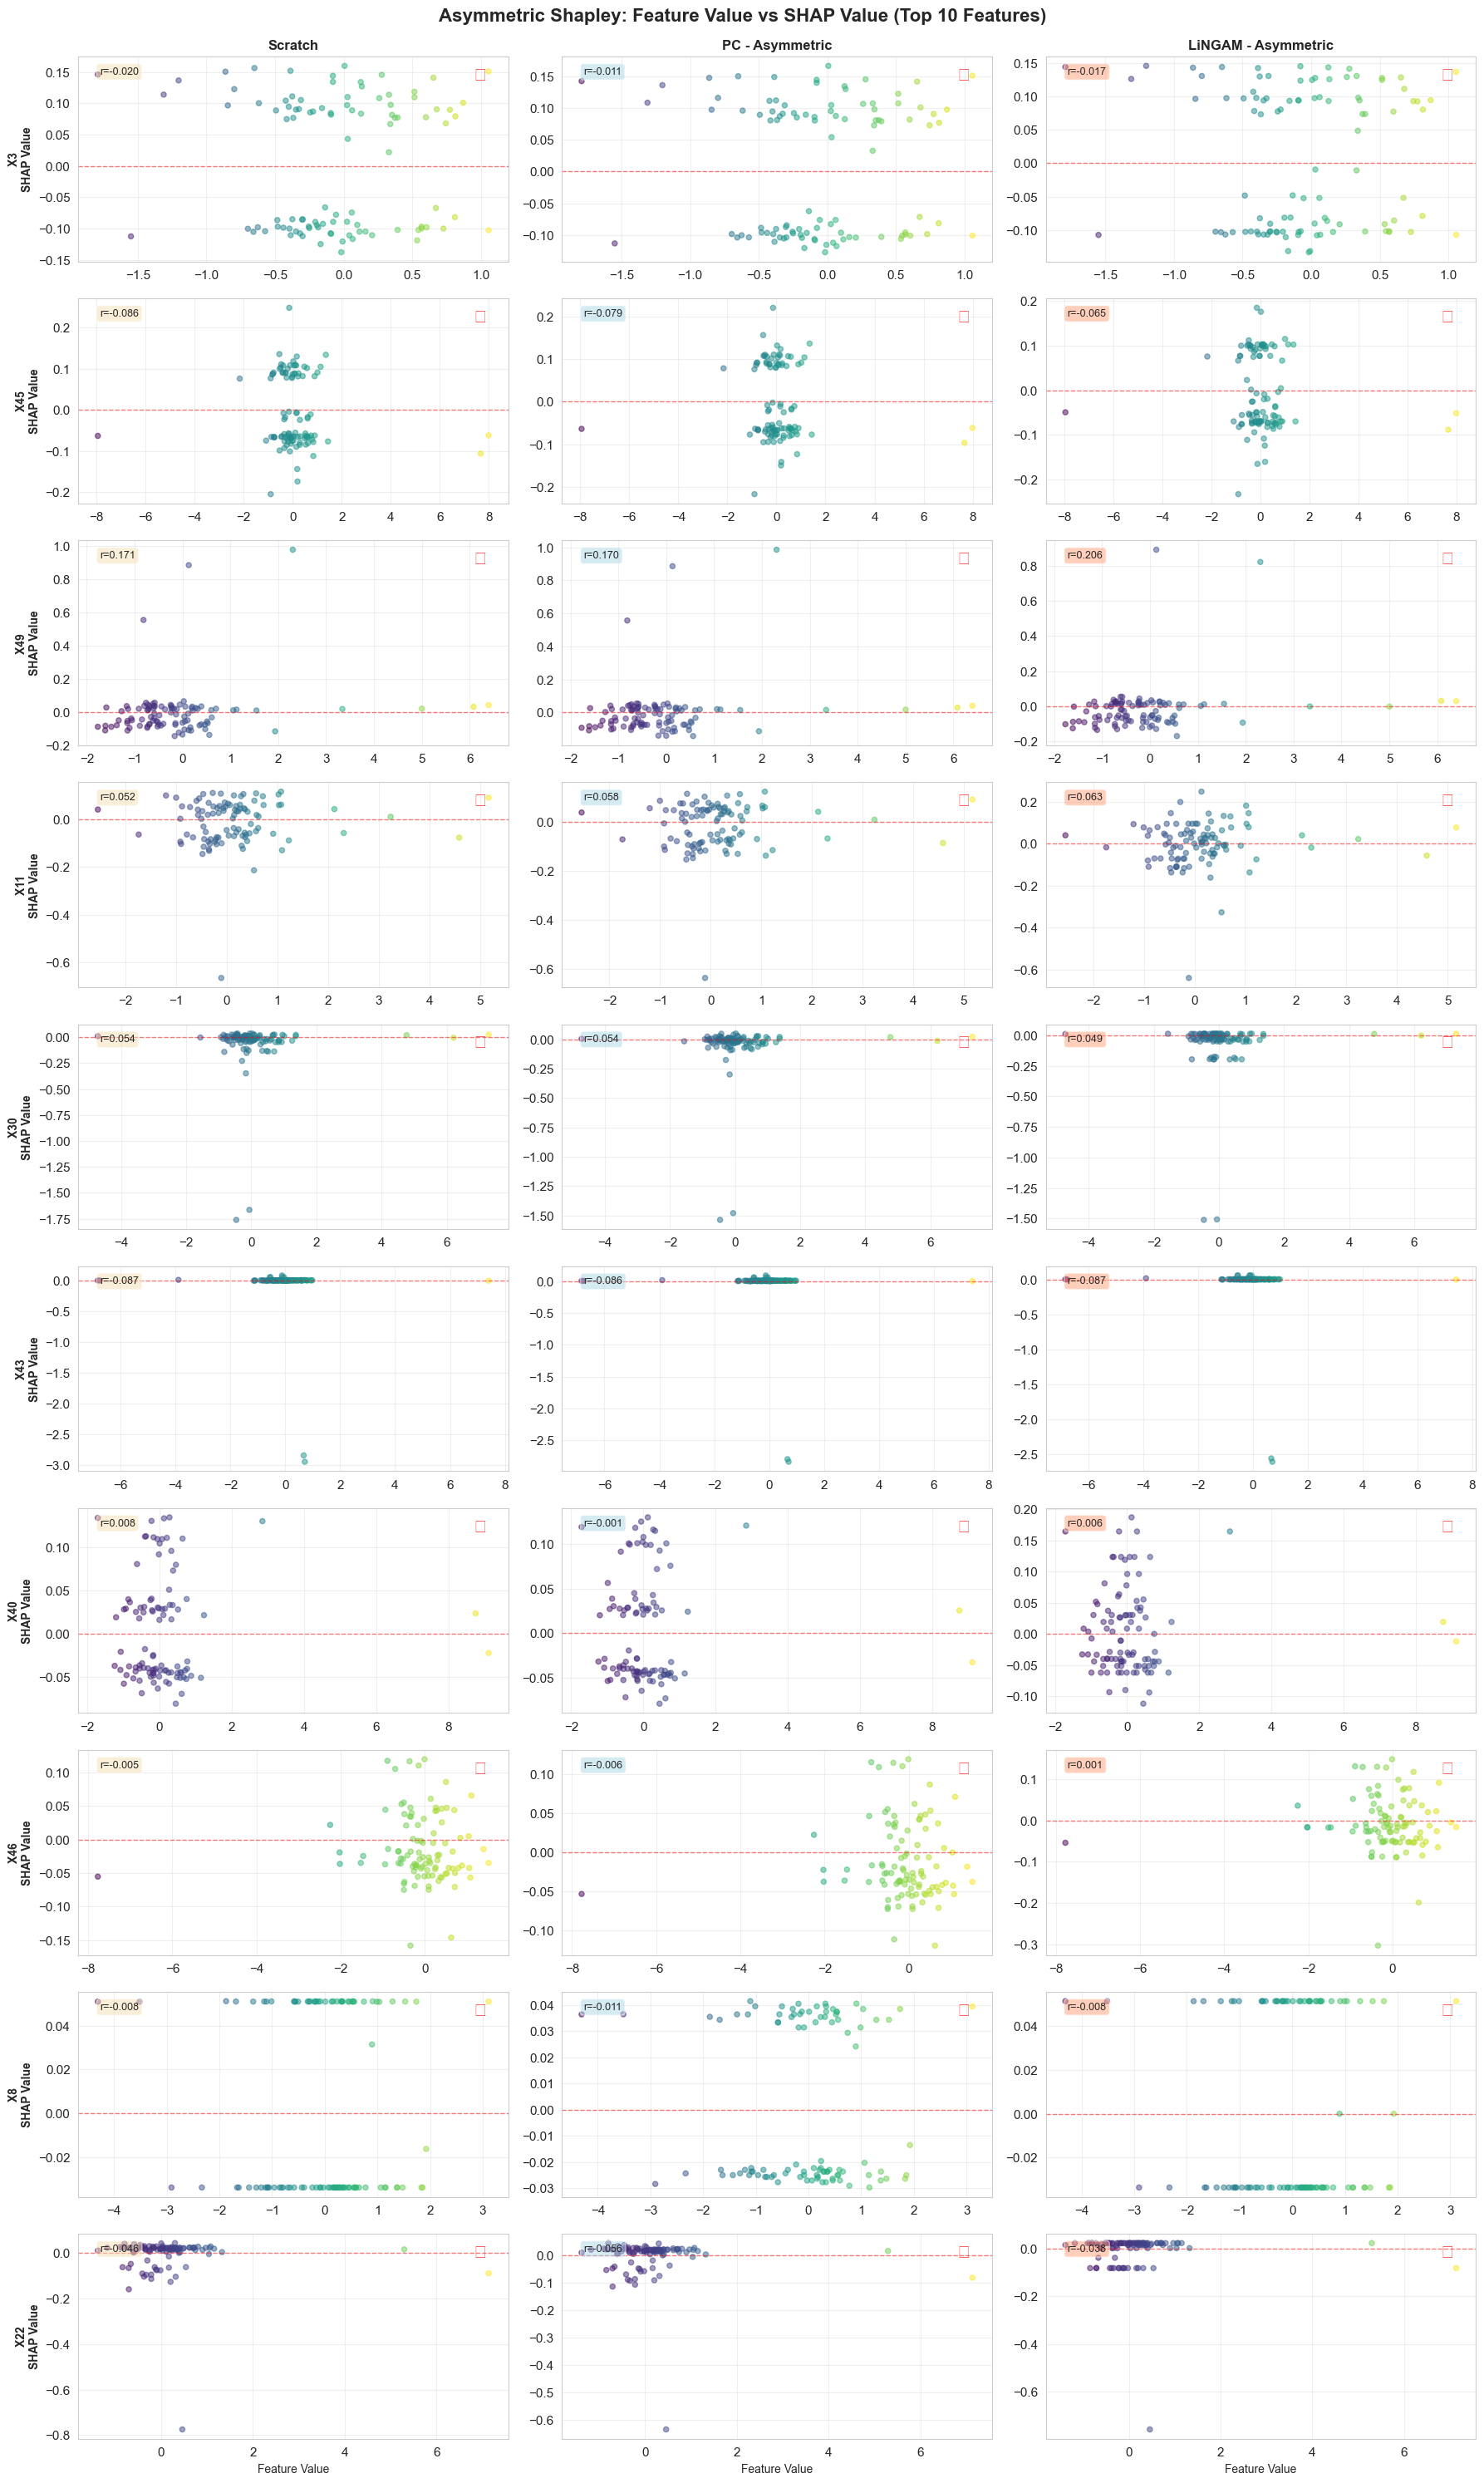

★ = True Y parent
r = Pearson correlation between feature value and SHAP value
Each point represents one test instance


In [28]:
# Create comprehensive dependence plots for Asymmetric Shapley
# Each row is a feature, columns are: Scratch, PC_Asym, LiNGAM_Asym

# First, load test data to match SHAP values
test_path = PROCESSED_DIR / f"{DATASET}_test.parquet"
test_data = pd.read_parquet(test_path)
X_test = test_data.drop(columns=['Y'])

# Match the number of samples with SHAP values
n_samples_shap = scratch_values.shape[0]
X_test_matched = X_test.iloc[:n_samples_shap, :]

print(f"Test data shape: {X_test.shape}")
print(f"SHAP values shape: {scratch_values.shape}")
print(f"Using first {n_samples_shap} test samples for plotting")

n_features_to_plot = 10  # Top 10 features
n_cols = 3  # Scratch, PC, LiNGAM

fig, axes = plt.subplots(n_features_to_plot, n_cols, figsize=(18, 3*n_features_to_plot))

for feat_idx, (idx, fname) in enumerate(zip(top_10_indices, top_10_features)):
    is_true_parent = idx in true_parents
    
    # Get feature values from test data (to match SHAP values)
    feature_values = X_test_matched.iloc[:, idx].values
    
    # Get SHAP values for this feature
    scratch_shap = scratch_values[:, idx]
    pc_asym_shap = pc_asym_values[:, idx]
    lingam_asym_shap = lingam_asym_values[:, idx]
    
    # Plot 1: Scratch
    ax = axes[feat_idx, 0]
    scatter = ax.scatter(feature_values, scratch_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel(f'{fname}\nSHAP Value', fontsize=10, fontweight='bold')
    if feat_idx == 0:
        ax.set_title('Scratch', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr_scratch = np.corrcoef(feature_values, scratch_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_scratch:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Mark if true parent
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 2: PC Asymmetric
    ax = axes[feat_idx, 1]
    scatter = ax.scatter(feature_values, pc_asym_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('PC - Asymmetric', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_pc = np.corrcoef(feature_values, pc_asym_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_pc:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 3: LiNGAM Asymmetric
    ax = axes[feat_idx, 2]
    scatter = ax.scatter(feature_values, lingam_asym_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('LiNGAM - Asymmetric', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_lingam = np.corrcoef(feature_values, lingam_asym_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_lingam:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')

plt.suptitle('Asymmetric Shapley: Feature Value vs SHAP Value (Top 10 Features)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("r = Pearson correlation between feature value and SHAP value")
print("Each point represents one test instance")

### 14.2 Causal Shapley: Feature Dependence Plots

/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1609867622.py:79: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()


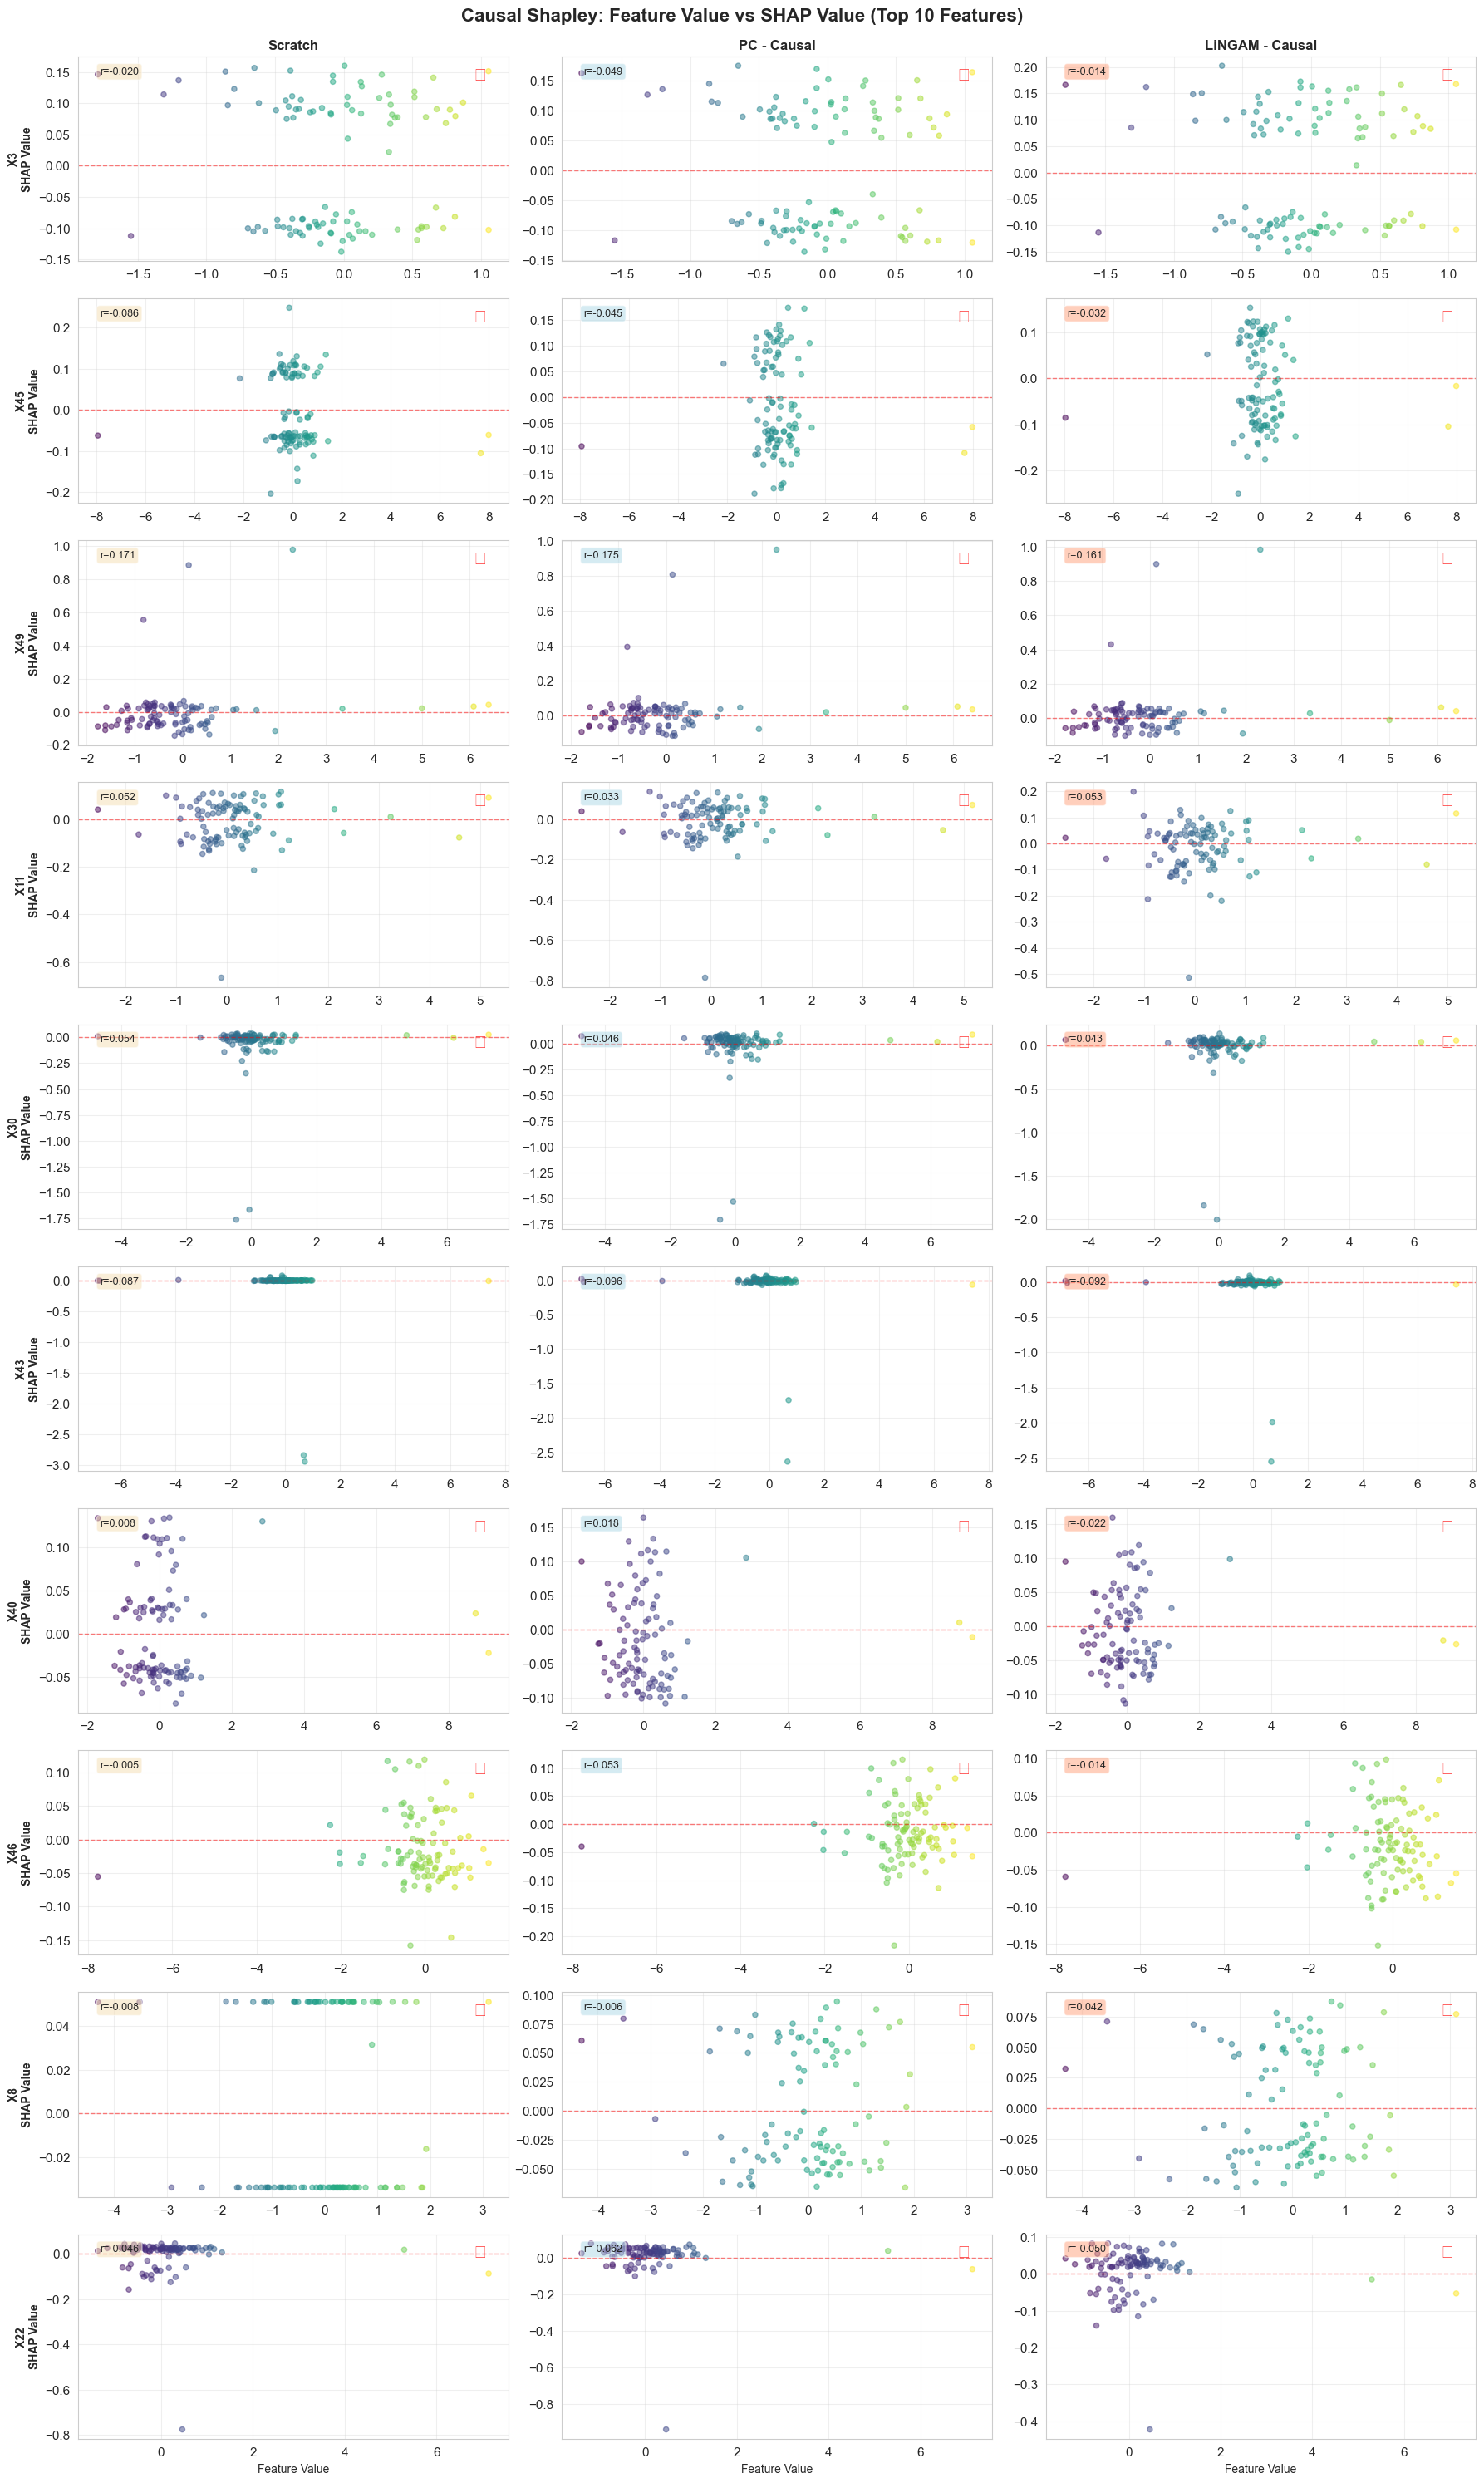

★ = True Y parent
r = Pearson correlation between feature value and SHAP value
Each point represents one test instance


In [29]:
# Create comprehensive dependence plots for Causal Shapley
# Each row is a feature, columns are: Scratch, PC_Causal, LiNGAM_Causal

fig, axes = plt.subplots(n_features_to_plot, n_cols, figsize=(18, 3*n_features_to_plot))

for feat_idx, (idx, fname) in enumerate(zip(top_10_indices, top_10_features)):
    is_true_parent = idx in true_parents
    
    # Get feature values from test data (to match SHAP values)
    feature_values = X_test_matched.iloc[:, idx].values
    
    # Get SHAP values for this feature
    scratch_shap = scratch_values[:, idx]
    pc_causal_shap = pc_causal_values[:, idx]
    lingam_causal_shap = lingam_causal_values[:, idx]
    
    # Plot 1: Scratch
    ax = axes[feat_idx, 0]
    scatter = ax.scatter(feature_values, scratch_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel(f'{fname}\nSHAP Value', fontsize=10, fontweight='bold')
    if feat_idx == 0:
        ax.set_title('Scratch', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr_scratch = np.corrcoef(feature_values, scratch_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_scratch:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Mark if true parent
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 2: PC Causal
    ax = axes[feat_idx, 1]
    scatter = ax.scatter(feature_values, pc_causal_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('PC - Causal', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_pc = np.corrcoef(feature_values, pc_causal_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_pc:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 3: LiNGAM Causal
    ax = axes[feat_idx, 2]
    scatter = ax.scatter(feature_values, lingam_causal_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('LiNGAM - Causal', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_lingam = np.corrcoef(feature_values, lingam_causal_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_lingam:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')

plt.suptitle('Causal Shapley: Feature Value vs SHAP Value (Top 10 Features)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("r = Pearson correlation between feature value and SHAP value")
print("Each point represents one test instance")

### 14.3 ShapleyFlow: Feature Dependence Plots

/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/qp/vvw_x_0134j4ssq5wp352csc0000gn/T/ipykernel_16552/1603124991.py:79: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()


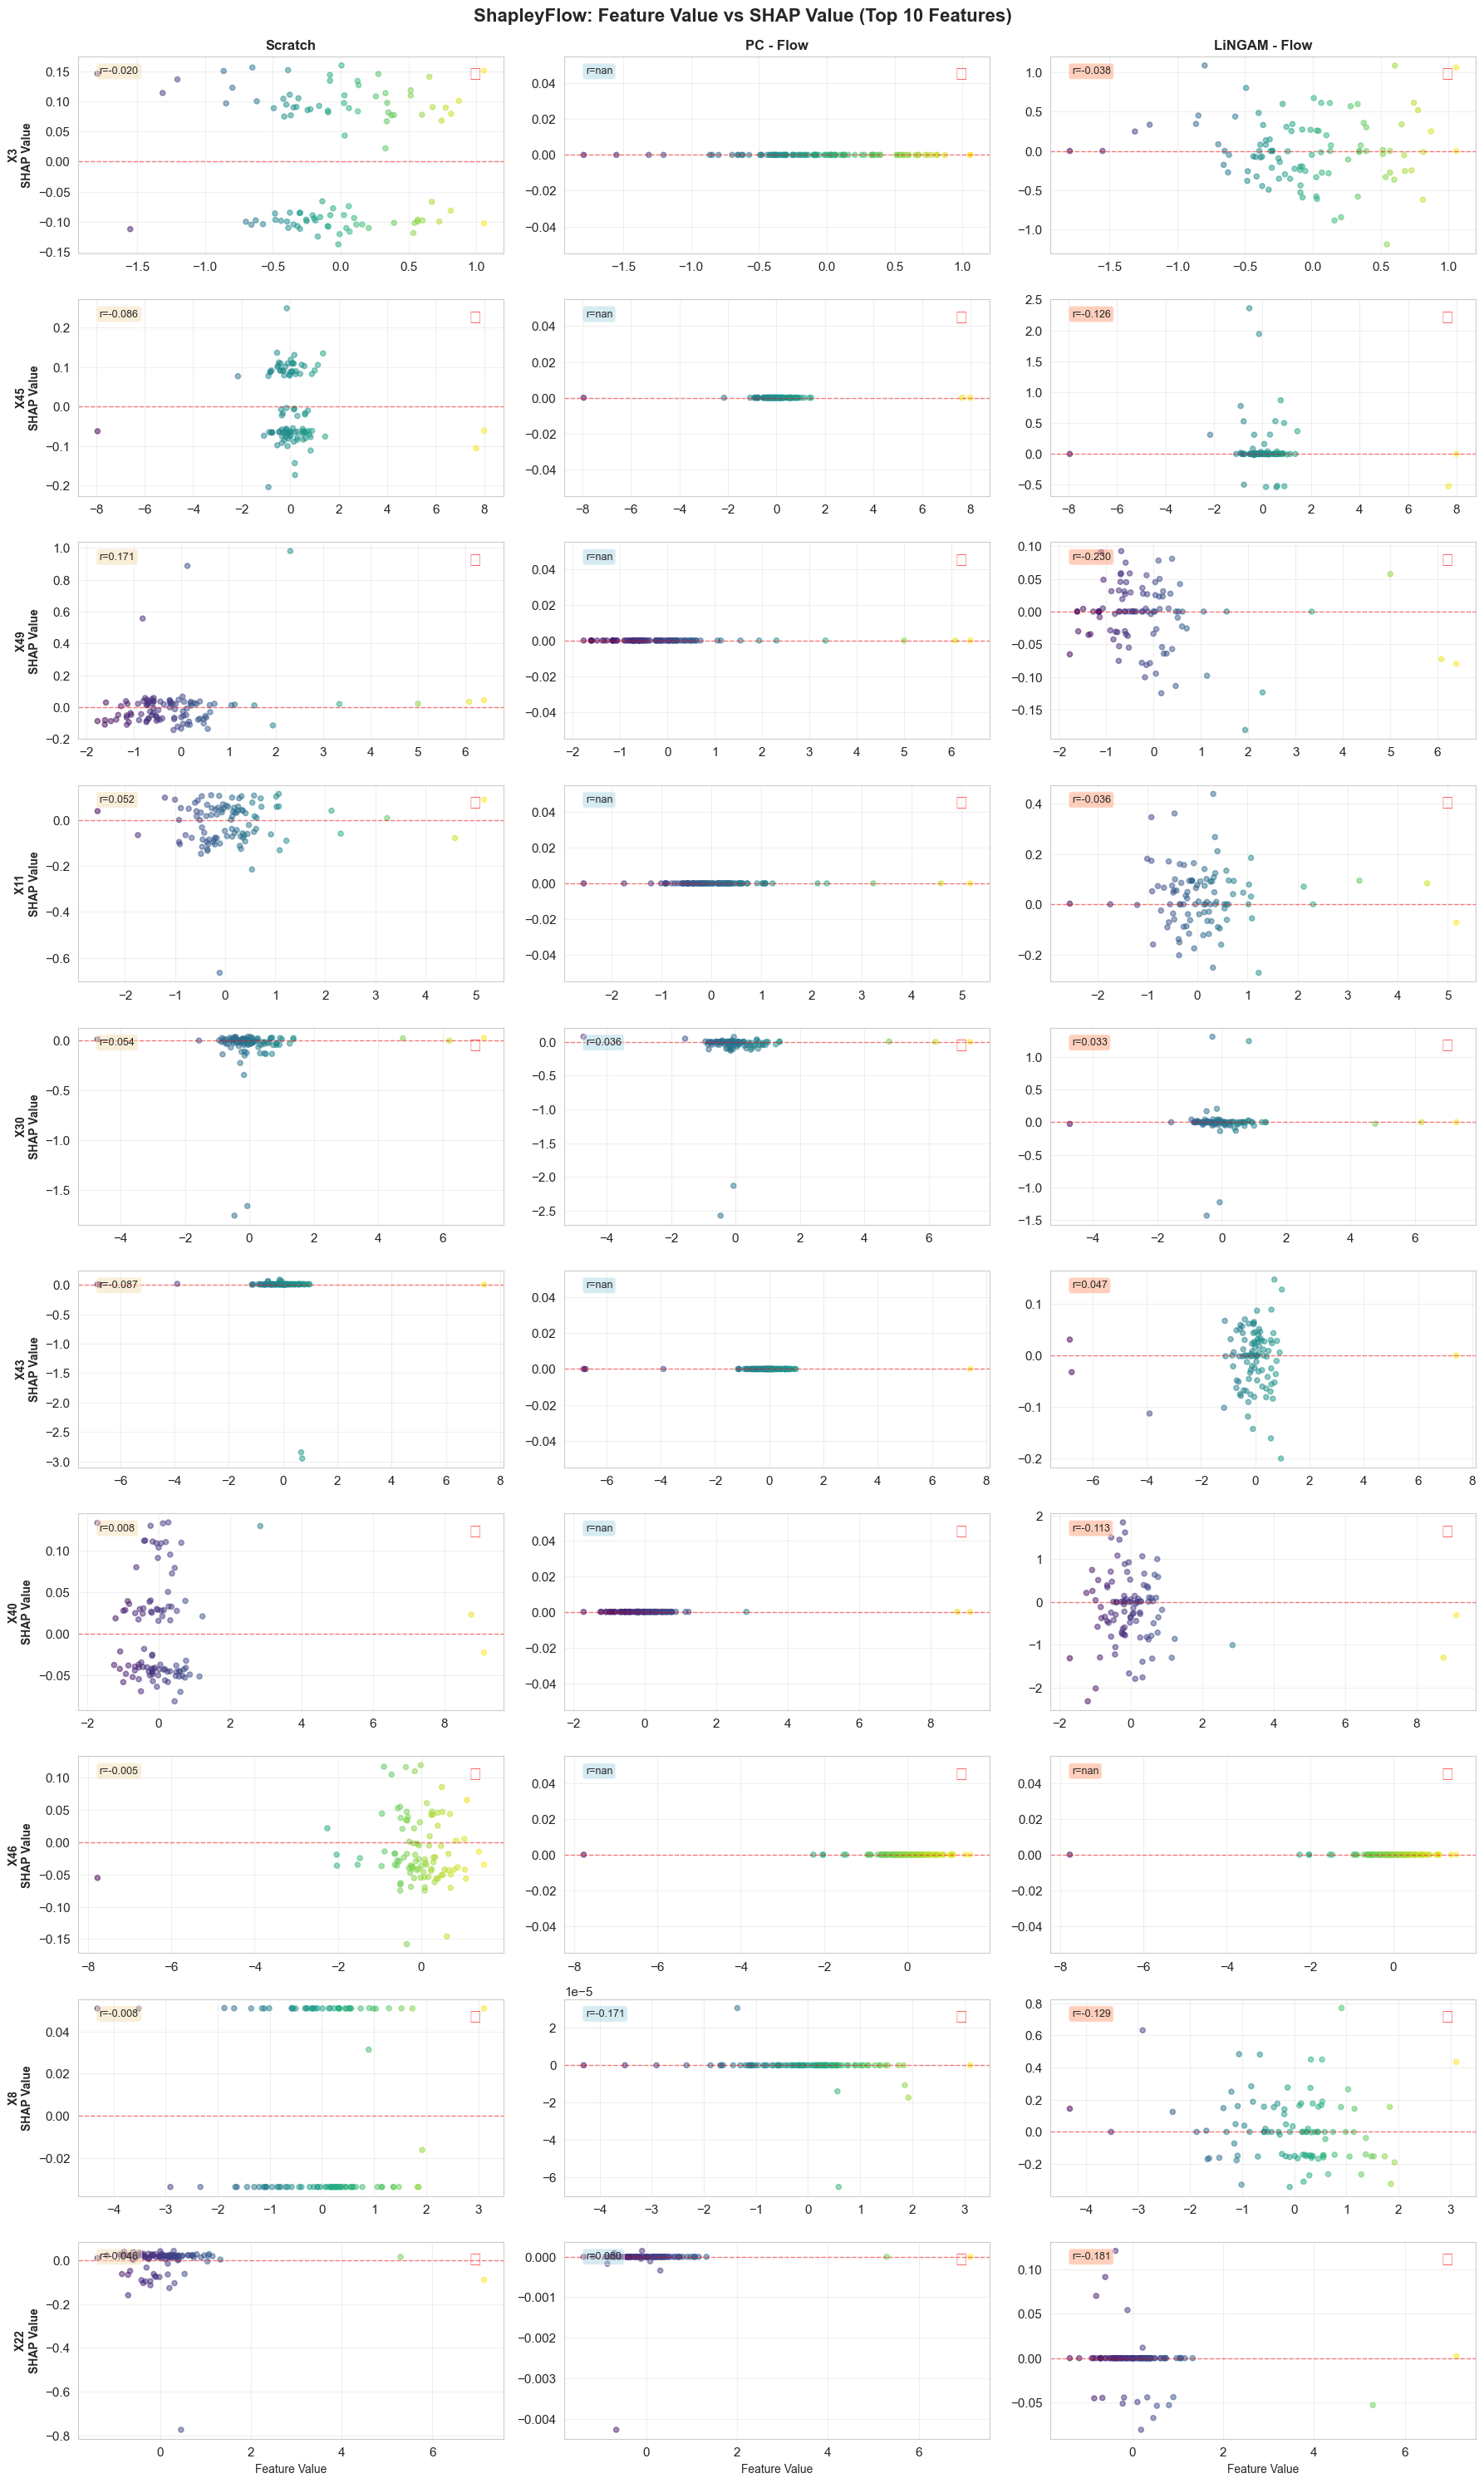

★ = True Y parent
r = Pearson correlation between feature value and SHAP value
Each point represents one test instance


In [30]:
# Create comprehensive dependence plots for ShapleyFlow
# Each row is a feature, columns are: Scratch, PC_Flow, LiNGAM_Flow

fig, axes = plt.subplots(n_features_to_plot, n_cols, figsize=(18, 3*n_features_to_plot))

for feat_idx, (idx, fname) in enumerate(zip(top_10_indices, top_10_features)):
    is_true_parent = idx in true_parents
    
    # Get feature values from test data (to match SHAP values)
    feature_values = X_test_matched.iloc[:, idx].values
    
    # Get SHAP values for this feature
    scratch_shap = scratch_values[:, idx]
    pc_flow_shap = pc_flow_values[:, idx]
    lingam_flow_shap = lingam_flow_values[:, idx]
    
    # Plot 1: Scratch
    ax = axes[feat_idx, 0]
    scatter = ax.scatter(feature_values, scratch_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel(f'{fname}\nSHAP Value', fontsize=10, fontweight='bold')
    if feat_idx == 0:
        ax.set_title('Scratch', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr_scratch = np.corrcoef(feature_values, scratch_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_scratch:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Mark if true parent
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 2: PC Flow
    ax = axes[feat_idx, 1]
    scatter = ax.scatter(feature_values, pc_flow_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('PC - Flow', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_pc = np.corrcoef(feature_values, pc_flow_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_pc:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')
    
    # Plot 3: LiNGAM Flow
    ax = axes[feat_idx, 2]
    scatter = ax.scatter(feature_values, lingam_flow_shap, alpha=0.5, s=20, c=feature_values, cmap='viridis')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    if feat_idx == 0:
        ax.set_title('LiNGAM - Flow', fontsize=12, fontweight='bold')
    if feat_idx == n_features_to_plot - 1:
        ax.set_xlabel('Feature Value', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    corr_lingam = np.corrcoef(feature_values, lingam_flow_shap)[0, 1]
    ax.text(0.05, 0.95, f'r={corr_lingam:.3f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.5))
    
    if is_true_parent:
        ax.text(0.95, 0.95, '★', transform=ax.transAxes, fontsize=16, color='red',
                verticalalignment='top', horizontalalignment='right')

plt.suptitle('ShapleyFlow: Feature Value vs SHAP Value (Top 10 Features)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("★ = True Y parent")
print("r = Pearson correlation between feature value and SHAP value")
print("Each point represents one test instance")

### 14.4 Summary of Feature Dependence Analysis

These dependence plots reveal several important insights:

1. **Feature-SHAP Relationships**: The correlation coefficient (r) shows how SHAP values change with feature values
   - Positive r: Higher feature values → Higher SHAP values (positive contribution)
   - Negative r: Higher feature values → Lower SHAP values (negative contribution)
   - Near-zero r: Non-linear or complex relationship

2. **Method Comparison**: 
   - **Scratch** (leftmost column): Standard SHAP without causal structure
   - **PC methods** (middle column): Incorporate causal graph learned via PC algorithm
   - **LiNGAM methods** (rightmost column): Incorporate causal graph learned via LiNGAM

3. **True Parents** (marked with ★):
   - Check if true Y parents show consistent patterns across methods
   - Compare their correlations with non-parent features

4. **Agreement Across Methods**:
   - Similar patterns across columns suggest method robustness
   - Divergent patterns indicate sensitivity to causal graph structure